In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")
import qRegNN_NFs_general as qrnn
import sklearn
import scipy
import sklearn.datasets as datasets
import h5py
import os
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
device = torch.device('cuda:0')
sys.path.append("quantiledatamc/auc95_pn_ctr/")
from run_pnet import simple_MLP, load_parts, PNetWrapper

In [2]:
base = "/nobackup/users/sambt/QR_samples/LHCO/"
f_bb1 = f"{base}/challenge/BB1/merged.h5"
f_ind_bb1 = f"{base}/challenge/BB1/split_indices.h5"
f_rd = f"{base}/rd/RD/merged.h5"
f_ind_rd = f"{base}/rd/RD/split_indices.h5"

fitvars = ['mjj','jet1_eta','jet2_eta','jet1_phi','jet1_phi',
           'jet1_pt','jet1_m','jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43']

with h5py.File(f_ind_rd,'r') as f:
    rd_test_idx = f['test_inds'][()]
    
with h5py.File(f_ind_bb1,'r') as f:
    bb1_test_idx = f['test_inds'][()]
    
with h5py.File(f_bb1,"r") as fp_b1:
    labels_b1 = np.loadtxt(f"{base}/challenge/BB1/events_LHCO2020_BlackBox1.masterkey")
    nev = len(labels_b1)
    b1 = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_test_idx]
    
with h5py.File(f_rd,"r") as frd:
    label = frd['label'][()]
    mask = label==0
    rd = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_test_idx]

In [16]:
with h5py.File("quantiledatamc/meanstd.h5","r") as f:
    tot1m = f['tot1m'][()]
    tot1s = f['tot1s'][()]

bb1_file = "/nobackup/users/sambt/QR_samples/LHCO/challenge/BB1/bkg_particleNet_test_sample.h5"
rd_file = "/nobackup/users/sambt/QR_samples/LHCO/rd/RD/bkg_particleNet_test_sample.h5"

rd_bkgtot=load_parts(rd_file,cutoff=False).numpy()
b1_bkgtot = load_parts(bb1_file,cutoff=False).numpy()
rd_bkgtot = (rd_bkgtot-tot1m)/tot1s
b1_bkgtot = (b1_bkgtot - tot1m)/tot1s

with h5py.File(bb1_file,"r") as f:
    b1_j1pt_ref = f['jet1_pt'][()]
with h5py.File(rd_file,"r") as f:
    rd_j1pt_ref = f['jet1_pt'][()]
print(np.all(b1_j1pt_ref==b1[:,5]))
print(np.all(rd_j1pt_ref==rd[:,5]))

/nobackup/users/sambt/QR_samples/LHCO/rd/RD/bkg_particleNet_test_sample.h5 <KeysViewHDF5 ['ce', 'ceta', 'cphi', 'cpt', 'cz', 'cze', 'jet1_eta', 'jet1_m', 'jet1_phi', 'jet1_pt', 'jet1_tau21', 'jet1_tau32', 'jet1_tau43']>
/nobackup/users/sambt/QR_samples/LHCO/challenge/BB1/bkg_particleNet_test_sample.h5 <KeysViewHDF5 ['ce', 'ceta', 'cphi', 'cpt', 'cz', 'cze', 'jet1_eta', 'jet1_m', 'jet1_phi', 'jet1_pt', 'jet1_tau21', 'jet1_tau32', 'jet1_tau43']>
True
True


In [17]:
rd_deta = np.abs(rd[:,1]-rd[:,2])
b1_deta = np.abs(b1[:,1]-b1[:,2])
rd_mjj = rd[:,0]
b1_mjj = b1[:,0]

rd_eta_sb = rd_deta>2
rd_eta_sr = rd_deta<=2
rd_mjj_sb = (rd_mjj<3300)|(rd_mjj>3700)
rd_mjj_sr = (rd_mjj>=3300)&(rd_mjj<=3700)

b1_eta_sb = b1_deta>2
b1_eta_sr = b1_deta<=2
b1_mjj_sb = (b1_mjj<3300)|(b1_mjj>3700)
b1_mjj_sr = (b1_mjj>=3300)&(b1_mjj<=3700)

In [5]:
encoder = torch.load("quantiledatamc/end_gpu_encodor_satori_full.pt").to(device)
with torch.no_grad():
    split_rd = np.array_split(np.arange(rd_bkgtot.shape[0]),rd_bkgtot.shape[0]//1000)
    split_b1 = np.array_split(np.arange(b1_bkgtot.shape[0]),b1_bkgtot.shape[0]//1000)
    rd_space = []
    b1_space = []
    for s in split_rd:
        rd_space.append(encoder(torch.tensor(rd_bkgtot[s],dtype=torch.float32,device=device)).detach().cpu().numpy())
    for s in split_b1:
        b1_space.append(encoder(torch.tensor(b1_bkgtot[s],dtype=torch.float32,device=device)).detach().cpu().numpy())
    rd_space = np.concatenate(rd_space,axis=0)
    b1_space = np.concatenate(b1_space,axis=0)

/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  
/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  # Remove the CWD from sys.path while we load stuff.


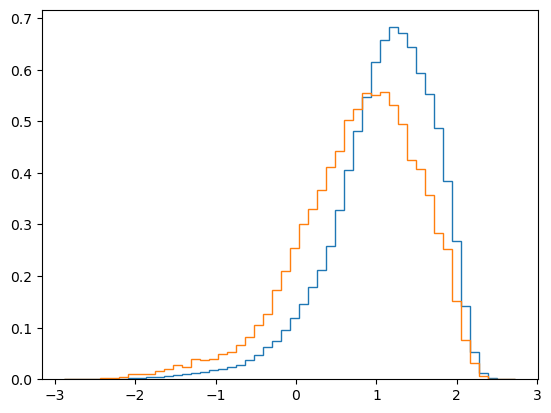

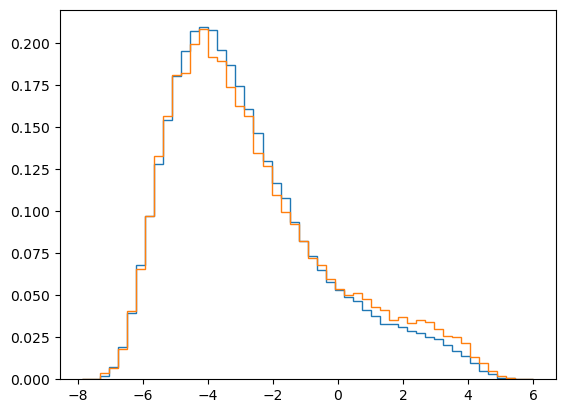

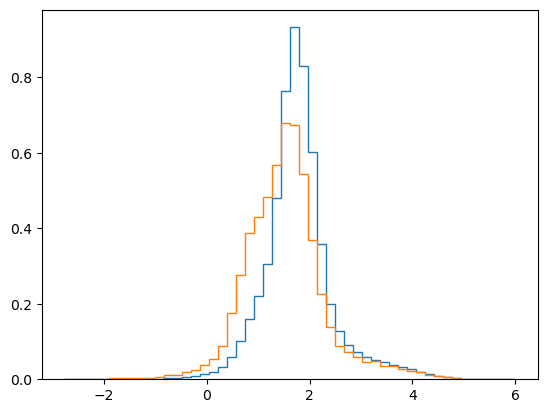

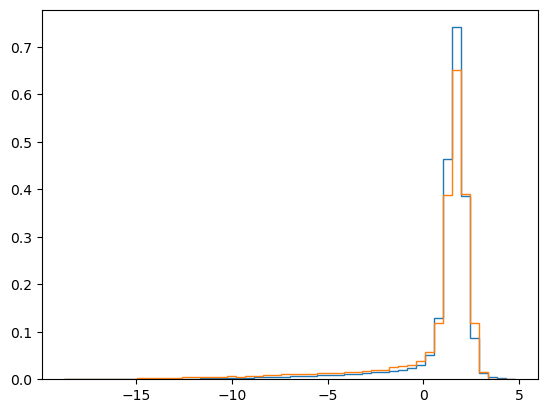

In [9]:
for i in range(rd_space.shape[1]):
    plt.figure()
    h1,bins,_ = plt.hist(rd_space[:,i][rd_mjj_sb],histtype='step',bins=50,density=True)
    h2,bins,_ = plt.hist(rd_space[:,i][rd_mjj_sr],histtype='step',bins=bins,density=True)
    #plt.yscale('log')

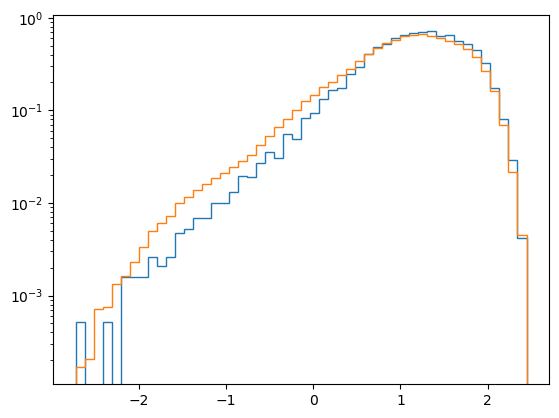

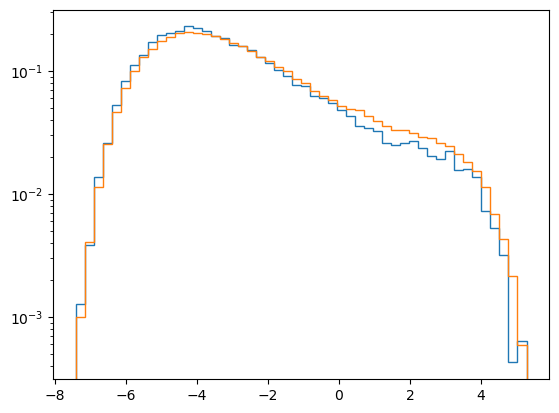

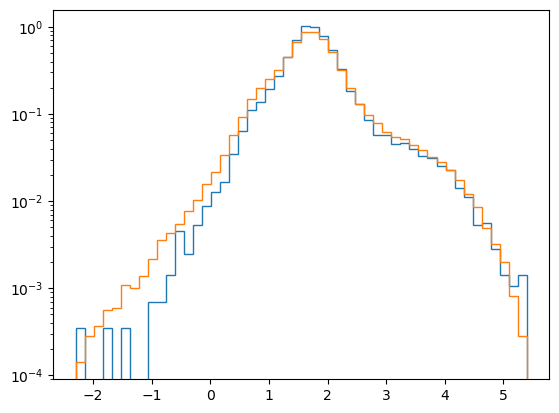

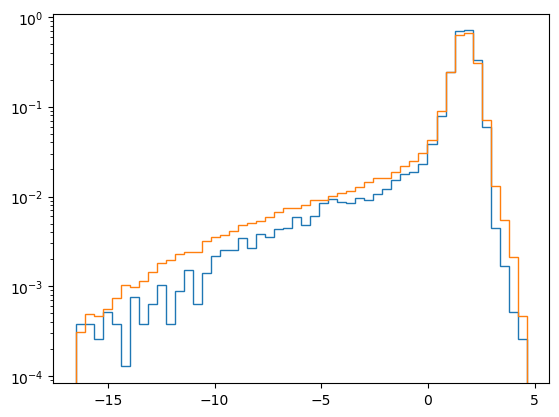

In [11]:
for i in range(rd_space.shape[1]):
    plt.figure()
    h1,bins,_ = plt.hist(rd_space[:,i][rd_eta_sb],histtype='step',bins=50,density=True)
    h2,bins,_ = plt.hist(rd_space[:,i][rd_eta_sr],histtype='step',bins=bins,density=True)
    plt.yscale('log')

In [22]:
b1_train,b1_test = train_test_split(b1_bkgtot[b1_mjj_sb],train_size=0.75)
rd_train,rd_test = train_test_split(rd_bkgtot[rd_mjj_sb],train_size=0.75)

train = np.concatenate((b1_train,rd_train),axis=0)
train_lab = np.concatenate((np.ones(b1_train.shape[0]),np.zeros(rd_train.shape[0]))).reshape(-1,1)
p = np.random.permutation(train.shape[0])
train,train_lab = train[p],train_lab[p]

test = np.concatenate((b1_test,rd_test),axis=0)
test_lab = np.concatenate((np.ones(b1_test.shape[0]),np.zeros(rd_test.shape[0]))).reshape(-1,1)
p = np.random.permutation(test.shape[0])
test,test_lab = test[p],test_lab[p]

In [23]:
# try with particlenet
pnet = PNetWrapper(train.shape[2],1,conv_params=[(8, (32, 32, 32)), (8, (64, 64, 64))],
            fc_params=[(128, 0.1)],use_fusion=False,use_fts_bn=False,use_counts=False,for_inference=False,for_segmentation=False,act_out=True)
pnet,loss,val_loss = qrnn.train_nn(pnet,train,train_lab,test,test_lab,
                                   n_epoch=10,lr=1e-4,bs=512,lossfunc="BCE",plot=False,losses=True)

Loss: 0.6523941159248352, p = 78: 100%|██████████| 6438/6438 [04:28<00:00, 23.94it/s]  


In [29]:
test_split = np.array_split(np.arange(len(test)),len(test)//1000)
rd_sr_split = np.array_split(np.arange(len(rd_bkgtot[rd_mjj_sr])),len(test)//1000)
pnet = pnet.to(device)
with torch.no_grad():
    test_wgts = []
    rd_sr_wgts = []
    for s in test_split:
        test_wgts.append(pnet(torch.tensor(test[s],dtype=torch.float32,device=device)).detach().cpu().numpy()[:,0])
    for s in rd_sr_split:
        rd_sr_wgts.append(pnet(torch.tensor(rd_bkgtot[rd_mjj_sr][s],dtype=torch.float32,device=device)).detach().cpu().numpy()[:,0])
    test_wgts=np.concatenate(test_wgts,axis=0)
    rd_sr_wgts=np.concatenate(rd_sr_wgts,axis=0)

In [30]:
encoder = torch.load("quantiledatamc/end_gpu_encodor_satori_full.pt").to(device)
with torch.no_grad():
    split_test = np.array_split(np.arange(test.shape[0]),test.shape[0]//1000)
    test_space = []
    for s in split_test:
        test_space.append(encoder(torch.tensor(test[s],dtype=torch.float32,device=device)).detach().cpu().numpy())
    test_space = np.concatenate(test_space,axis=0)
test_rd_space = test_space[test_lab[:,0]==0]
test_rd_wgts = test_wgts[test_lab[:,0]==0]
test_b1_space = test_space[test_lab[:,0]==1]
test_b1_wgts = test_wgts[test_lab[:,0]==1]

In [31]:
def triplet(ref,uncorr,weights,axes,names,colors,bins=50,xlim=None):
    plt.sca(axes[0])
    h1,bins,_ = plt.hist(ref,bins=bins,histtype='step',label=names[0],density=True,color=colors[0],fill=True,alpha=0.5)
    h3,bins,_ = plt.hist(uncorr,bins=bins,histtype='step',label=names[1],density=True,color=colors[1],linewidth=3)
    h2,bins,_ = plt.hist(uncorr,weights=weights,bins=bins,histtype='step',label=names[2],density=True,color=colors[2],linewidth=3)
    h1c,bins = np.histogram(ref,bins=bins)
    h3c,bins = np.histogram(uncorr,bins=bins)
    h2c,bins = np.histogram(uncorr,weights=weights,bins=bins)
    if xlim is not None:
        plt.xlim(xlim)
    plt.legend()
    plt.sca(axes[1])
    w = bins[1]-bins[0]
    c = (bins[1:]+bins[:-1])/2
    h = np.divide(h2,h1,where=h1>0)
    herr = np.abs(h)*np.sqrt(np.divide(1.0,h2c.astype(np.float32),out=np.zeros_like(h2c.astype(np.float32)),where=h2c>0) + np.divide(1.0,h1c.astype(np.float32),out=np.zeros_like(h1c.astype(np.float32)),where=h1c>0))
    plt.errorbar(c,h,yerr=herr,color=colors[2],linewidth=0,markersize=15,marker='.',elinewidth=2,capsize=3,capthick=2)
    h = np.divide(h3,h1,where=h1>0)
    herr = np.abs(h)*np.sqrt(np.divide(1.0,h3c.astype(np.float32),out=np.zeros_like(h3c.astype(np.float32)),where=h3c>0) + np.divide(1.0,h1c.astype(np.float32),out=np.zeros_like(h1c.astype(np.float32)),where=h1c>0))
    plt.errorbar(c,h,yerr=herr,color=colors[1],linewidth=0,markersize=15,marker='.',elinewidth=2,capsize=3,capthick=2)
    if xlim is not None:
        plt.xlim(xlim)
    plt.ylim([0,2])
    plt.yticks(np.arange(0,2.5,0.5))
    plt.grid(axis='y')

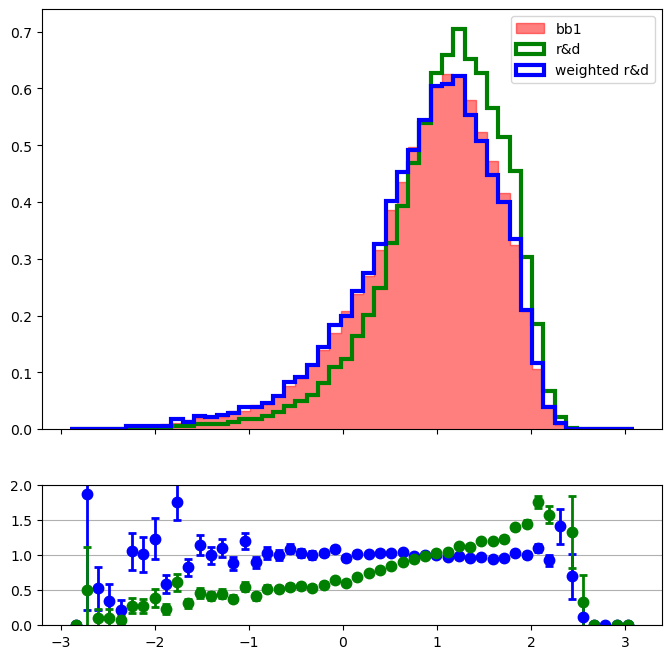

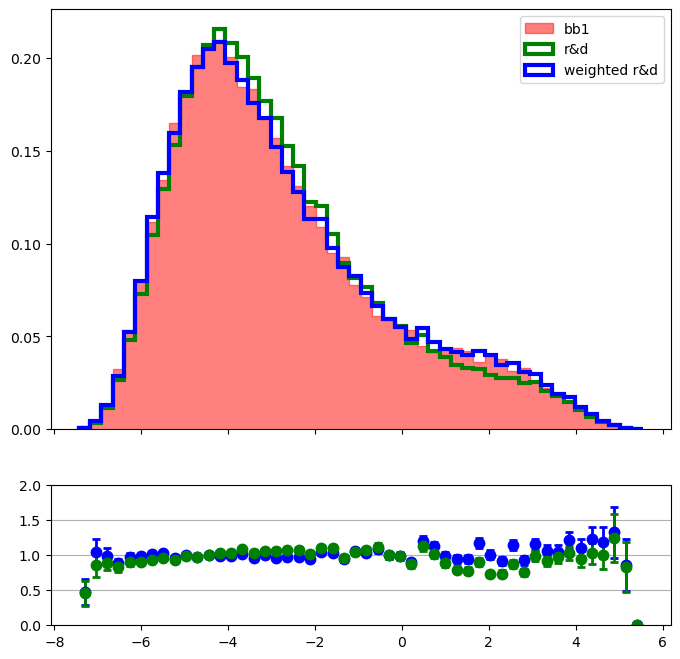

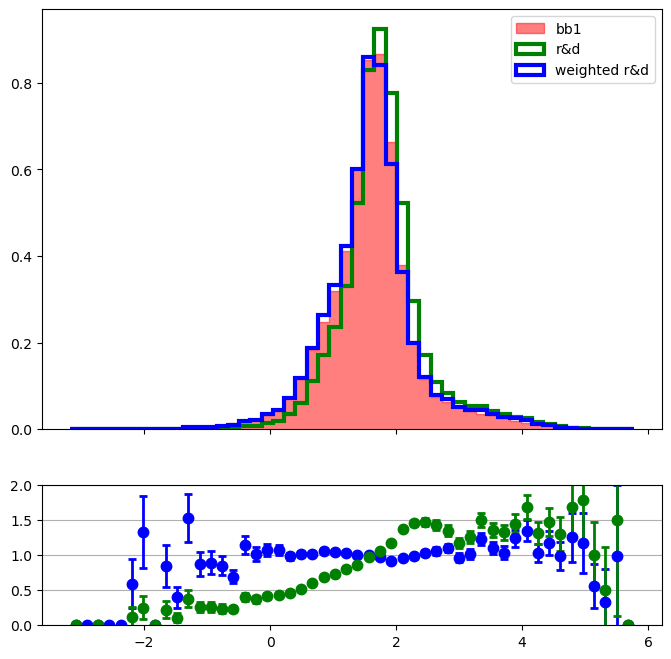

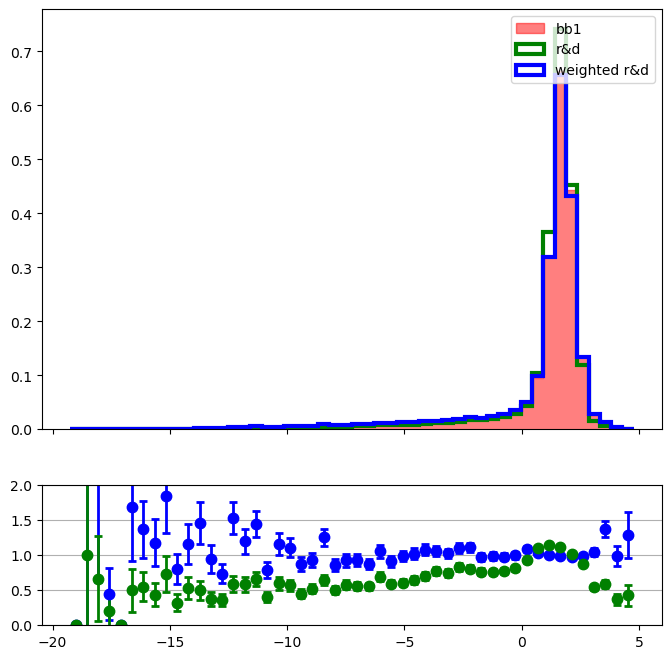

In [32]:
for i in range(test_rd_space.shape[1]):
    fig,axes = plt.subplots(figsize=(8,8),nrows=2,ncols=1,gridspec_kw={'height_ratios':[3,1]},sharex=True)
    triplet(test_b1_space[:,i],test_rd_space[:,i],test_rd_wgts/(1-test_rd_wgts),axes,names=['bb1','r&d','weighted r&d'],colors=['r','g','b'])

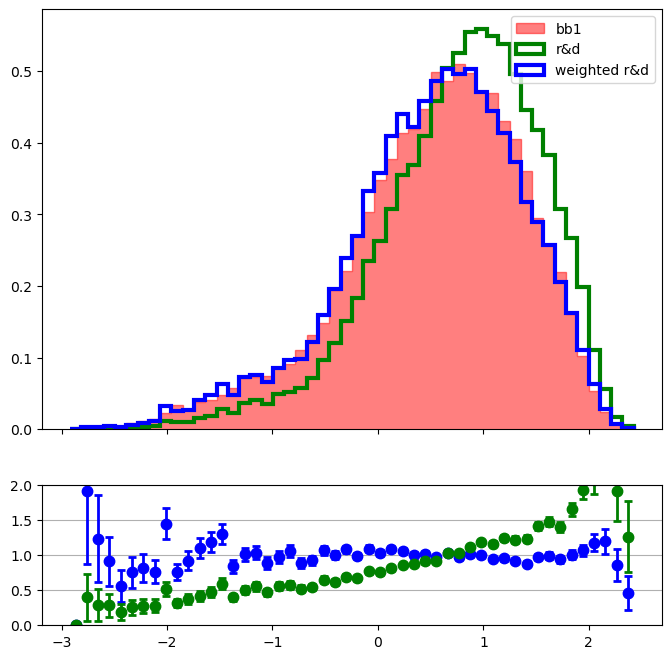

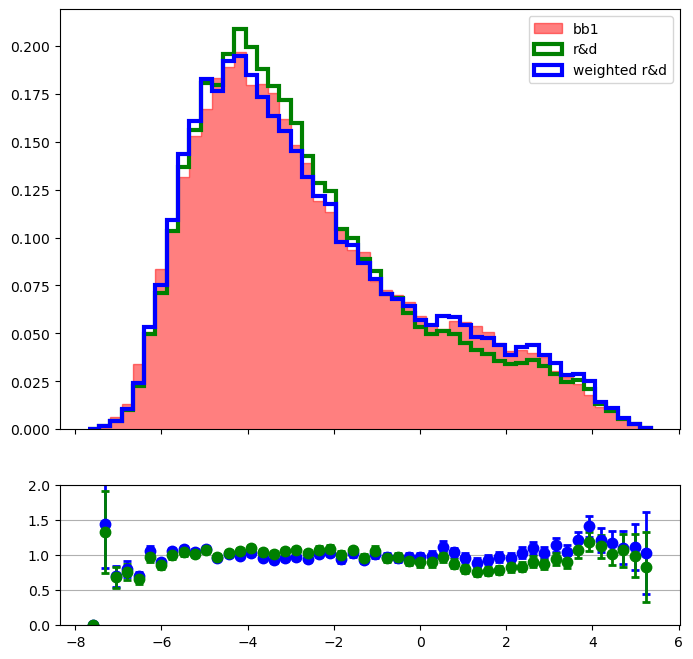

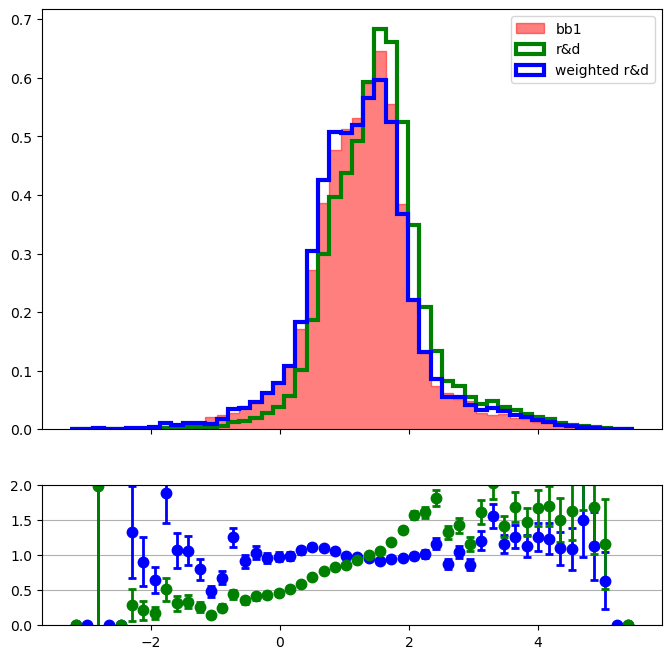

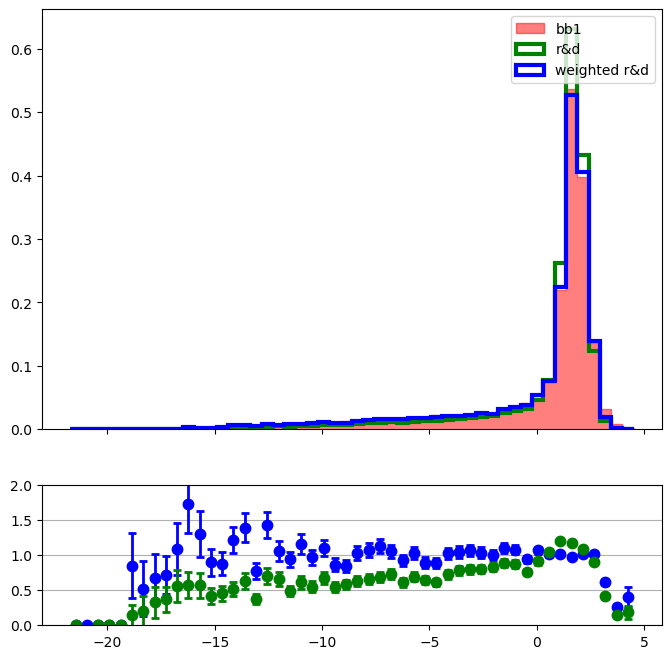

In [33]:
for i in range(test_rd_space.shape[1]):
    fig,axes = plt.subplots(figsize=(8,8),nrows=2,ncols=1,gridspec_kw={'height_ratios':[3,1]},sharex=True)
    triplet(b1_space[b1_mjj_sr][:,i],rd_space[rd_mjj_sr][:,i],rd_sr_wgts/(1-rd_sr_wgts),axes,names=['bb1','r&d','weighted r&d'],colors=['r','g','b'])

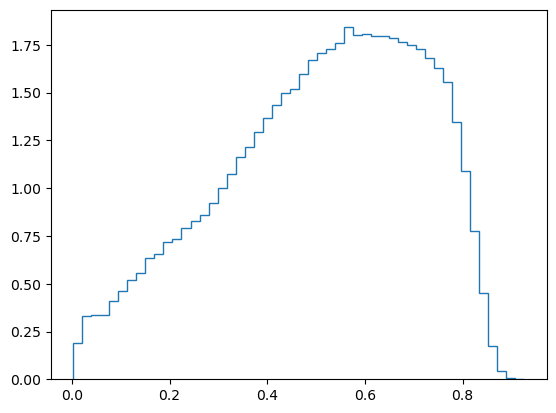

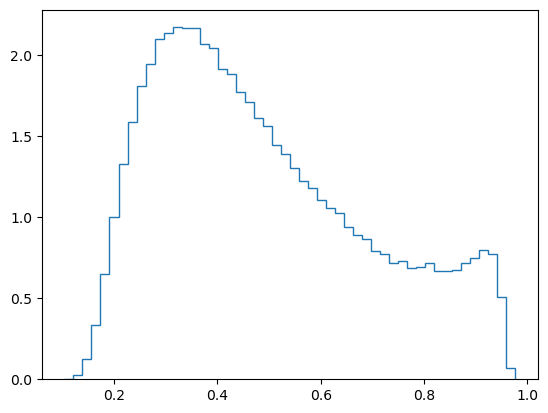

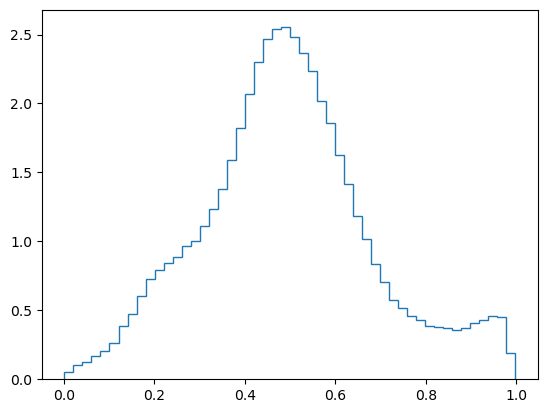

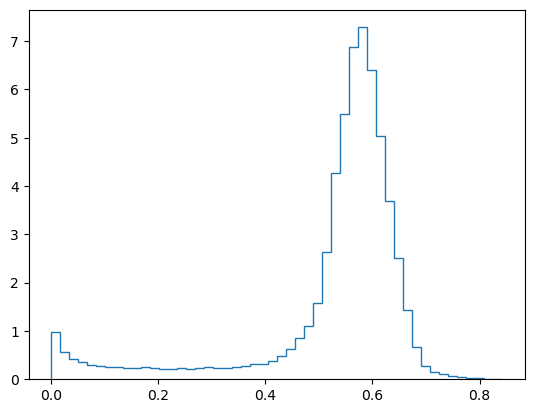

In [43]:
def sigmoid(x,a=1):
    return 1/(1+np.exp(-a*x))
norm = (rd_space-rd_space.mean(axis=0))/rd_space.std(axis=0)
for i in range(rd_space.shape[1]):
    plt.figure()
    h=plt.hist(sigmoid(norm[:,i],a=1),bins=50,histtype='step',density=True)
    #plt.yscale('log')

# Train flows

In [3]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":15,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
rangeScale = 3
variables = fitvars
trainer = qrnn.chainedNFTrainer("LHCO_PythRDBB1_mjjSideband_jets12",rd_train,rd_test,b1_train,b1_test,fitvars,control=[0],
                                NF_kwargs=NF_kwargs,rangeScale=rangeScale,separateScale=False)

## jet1 rho

Training flow bkgFlow_step0_jet1_rho


Loss: 1.2661651742458344, p = 133: 100%|██████████| 878/878 [03:26<00:00,  4.24it/s]


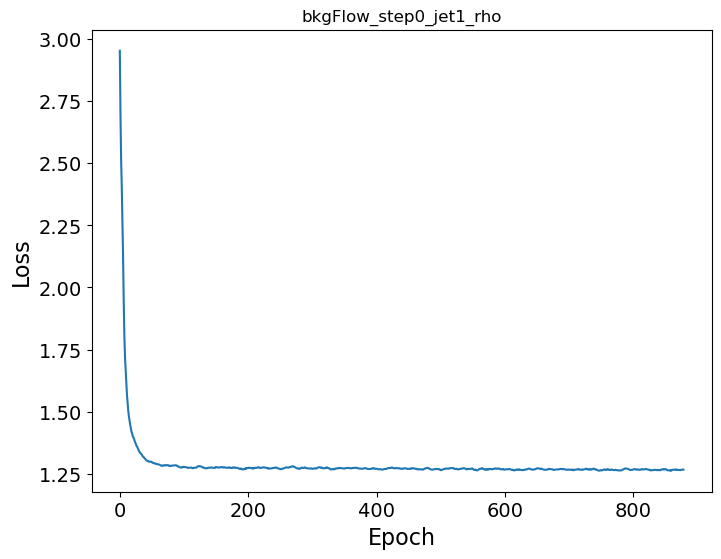

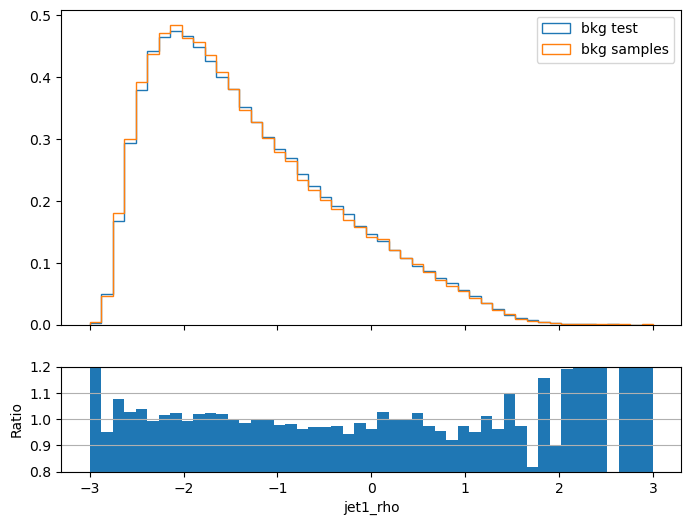

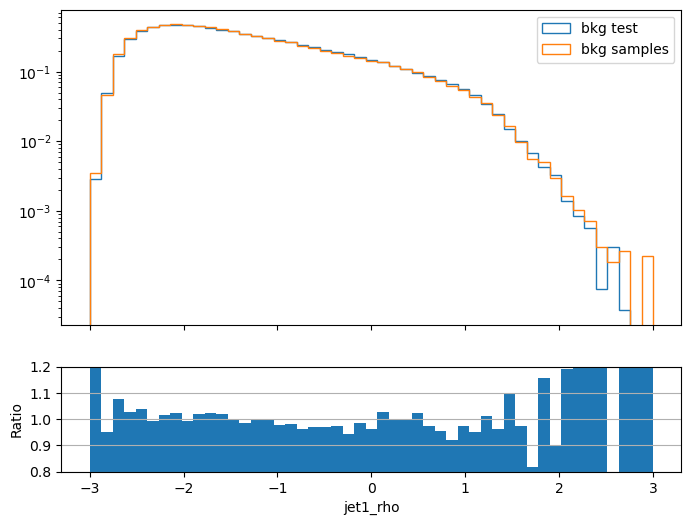

In [5]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":1,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step0_jet1_rho


Loss: 1.3167117989063264, p = 158: 100%|██████████| 878/878 [03:10<00:00,  4.61it/s]


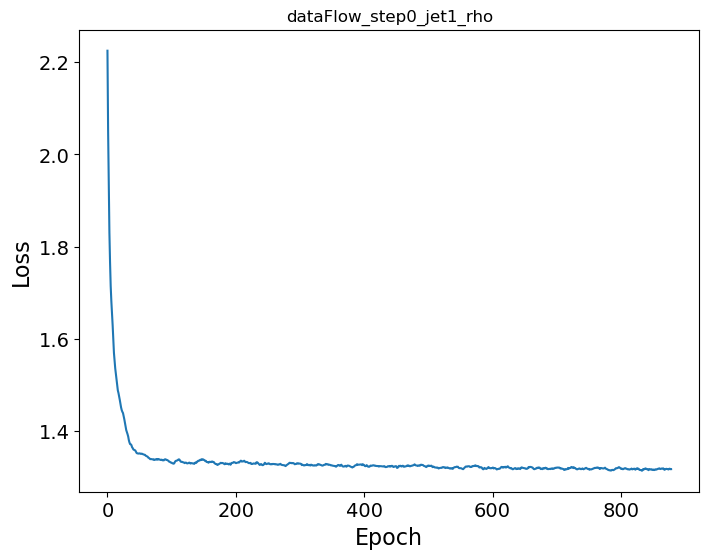

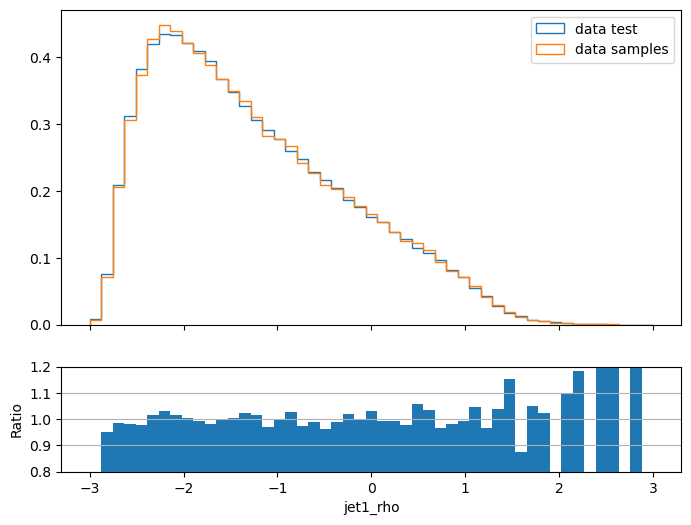

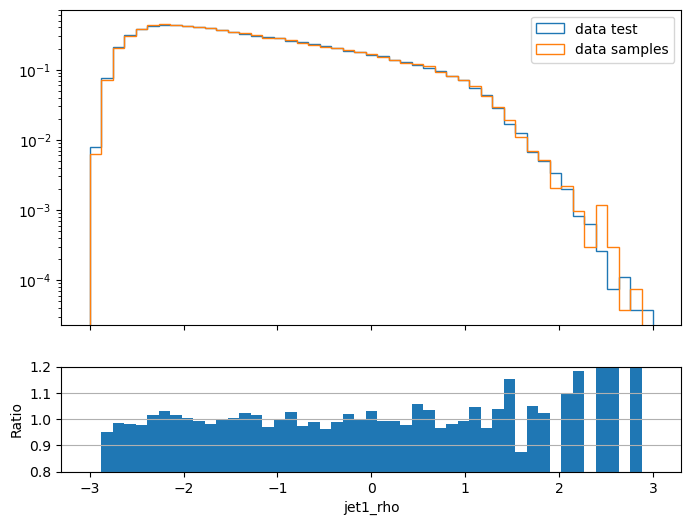

In [6]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":80,"num_blocks_per_layer":1,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 22/22 [00:01<00:00, 13.93it/s]


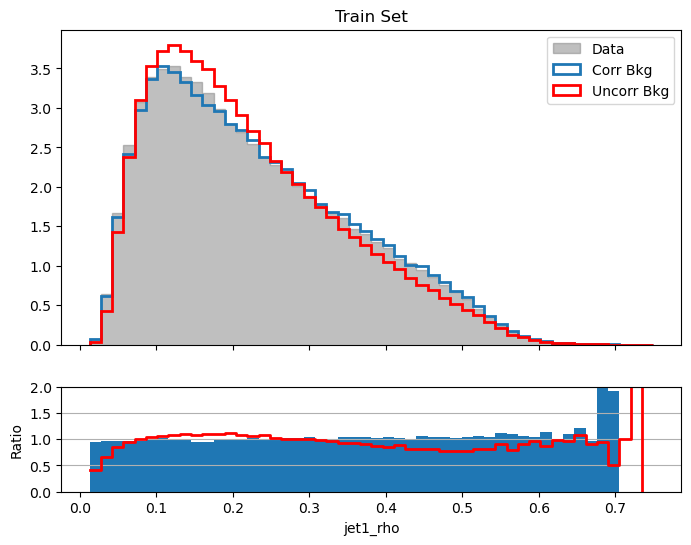

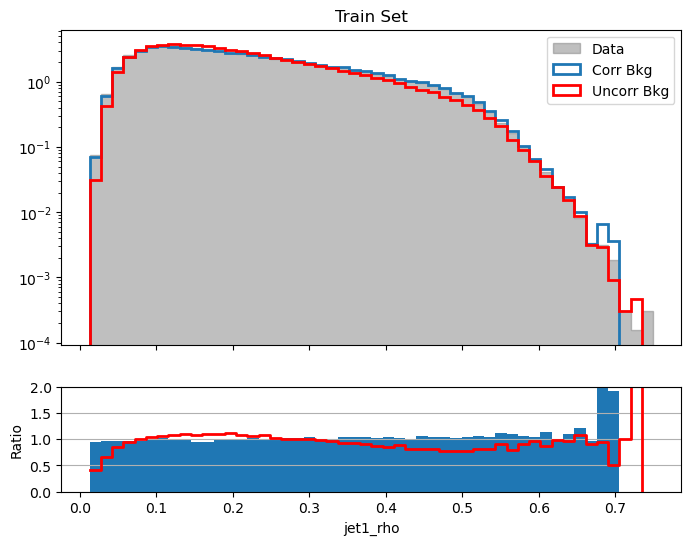

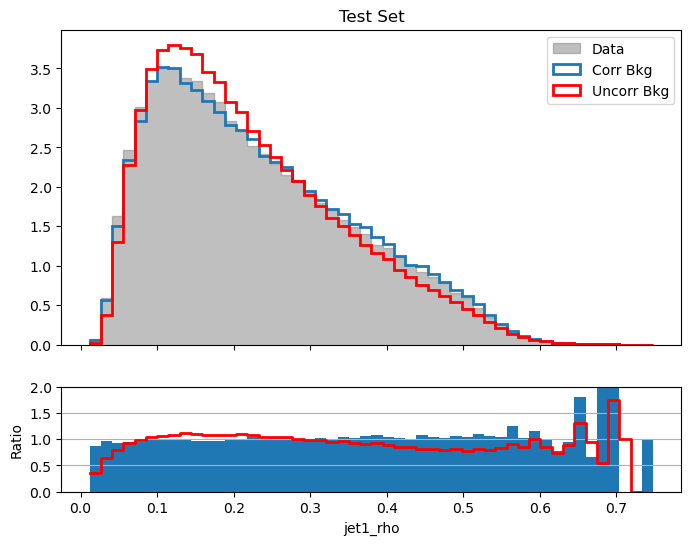

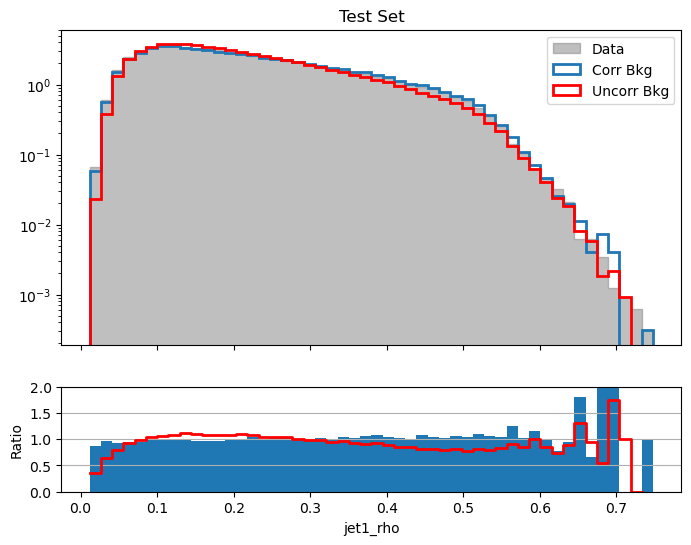

In [7]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [8]:
trainer.stepForward()

## jet1 tau21

Training flow bkgFlow_step1_jet1_tau21


Loss: 1.3493018579483032, p = 254: 100%|██████████| 878/878 [03:38<00:00,  4.01it/s]


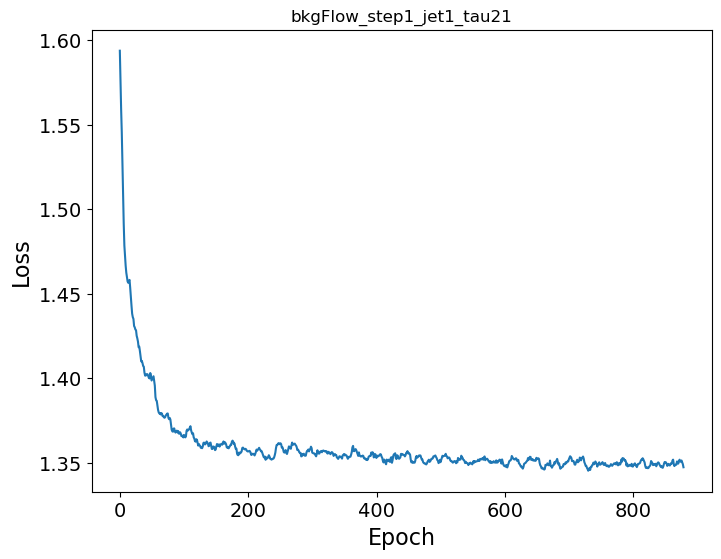

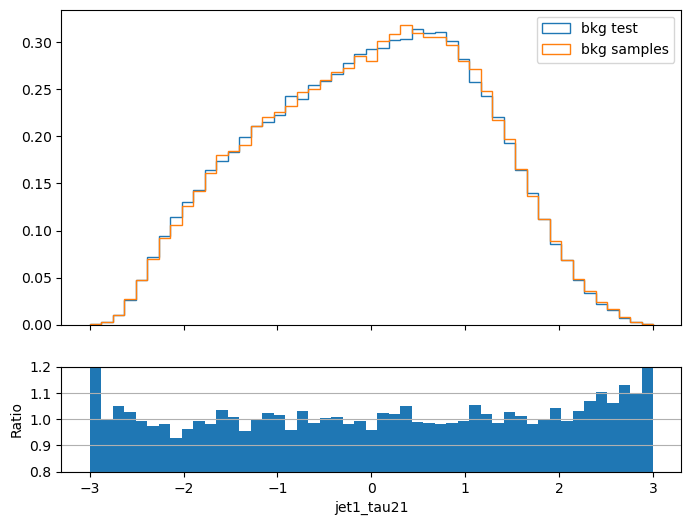

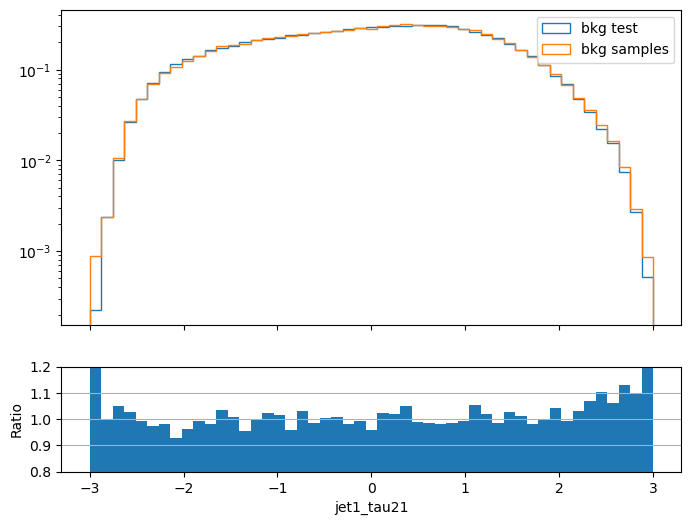

In [9]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step1_jet1_tau21


Loss: 1.3604350900650024, p = 407: 100%|██████████| 878/878 [03:21<00:00,  4.35it/s]


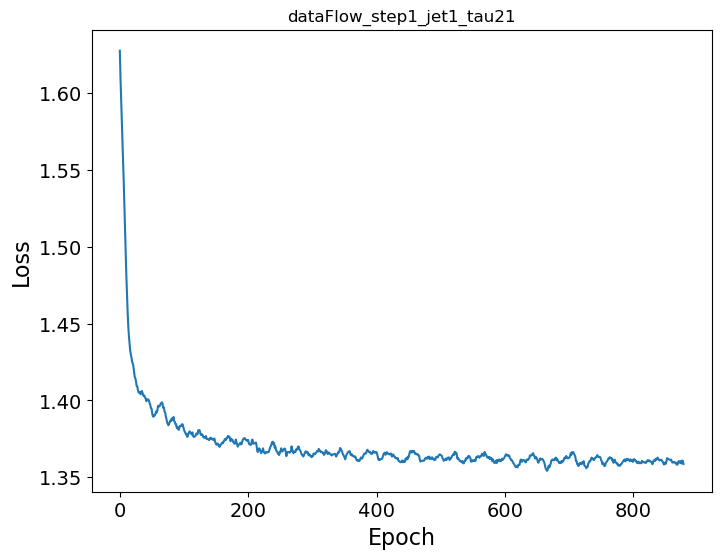

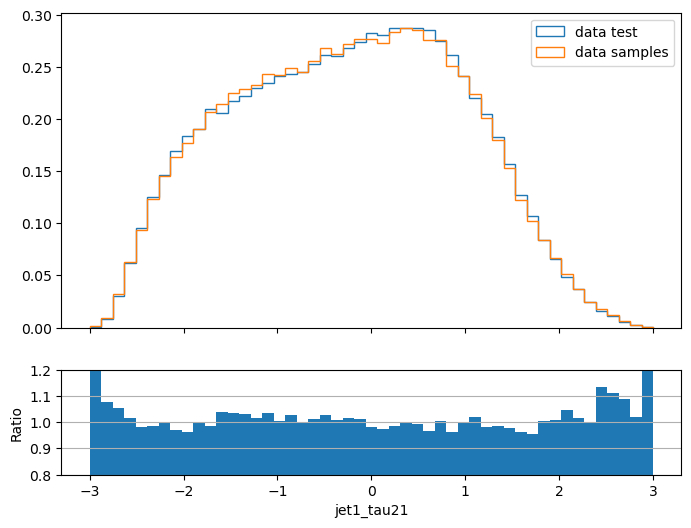

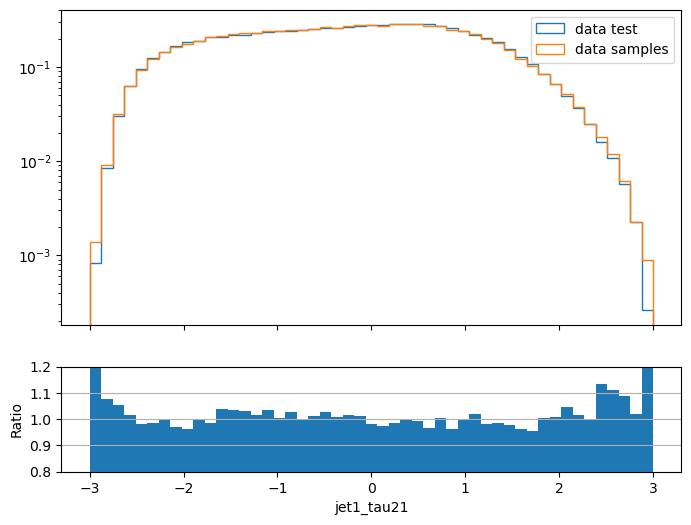

In [10]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 22/22 [00:02<00:00, 10.95it/s]


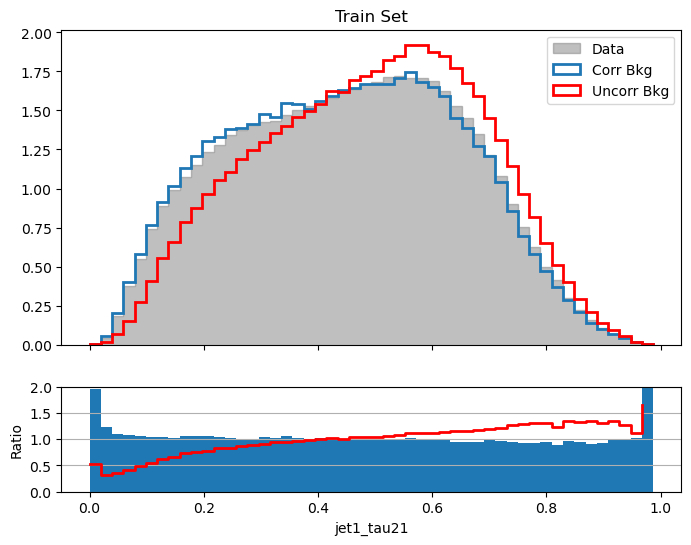

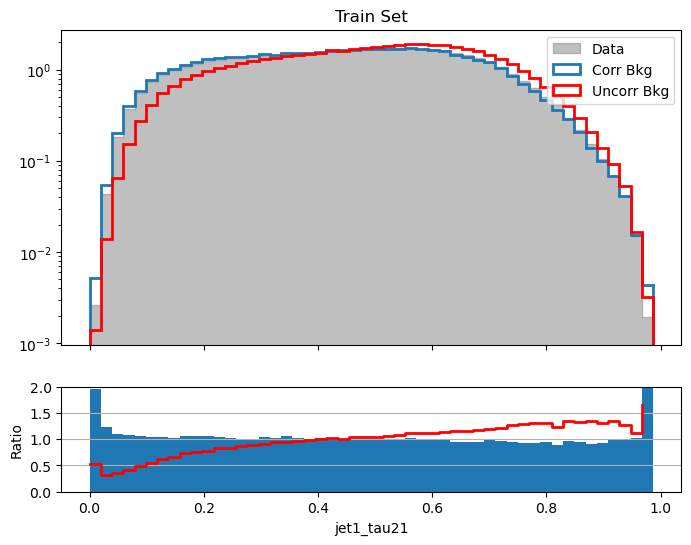

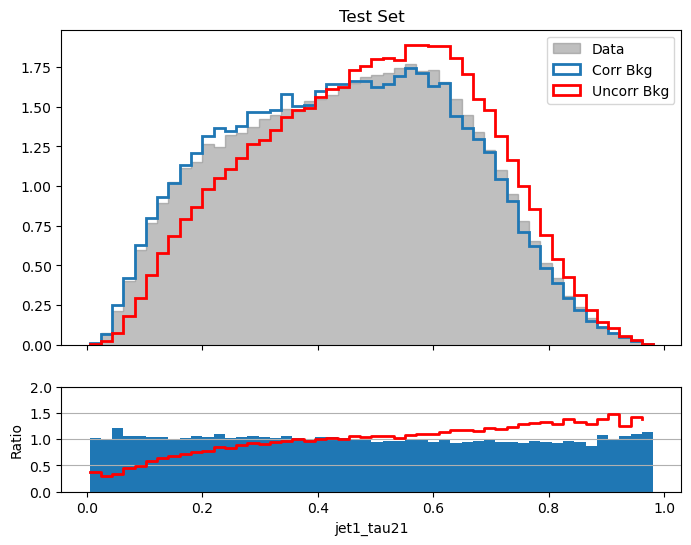

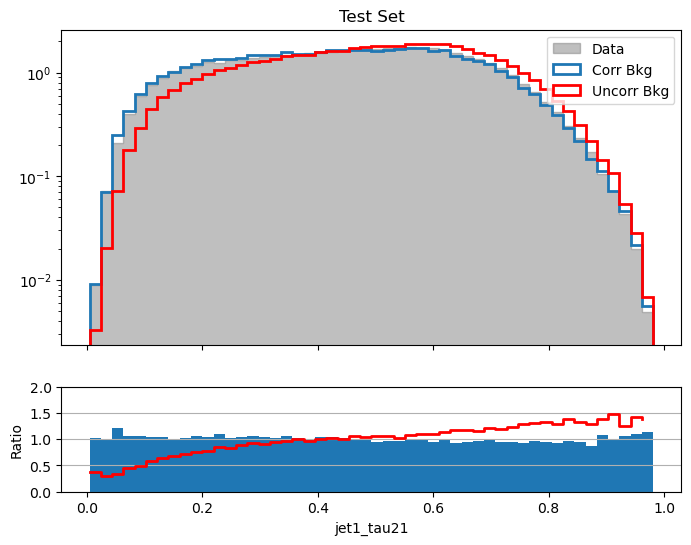

In [11]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [12]:
trainer.stepForward()

## jet1 tau32

Training flow bkgFlow_step2_jet1_tau32


Loss: 0.8280530154705048, p = 373: 100%|██████████| 878/878 [02:59<00:00,  4.90it/s]


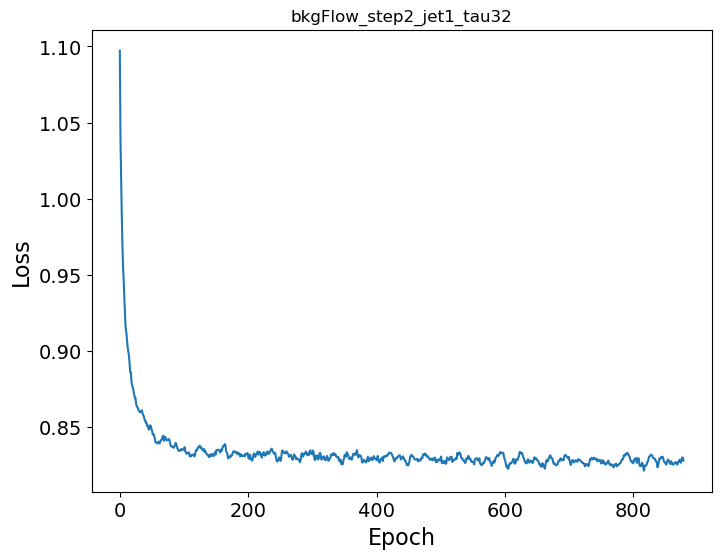

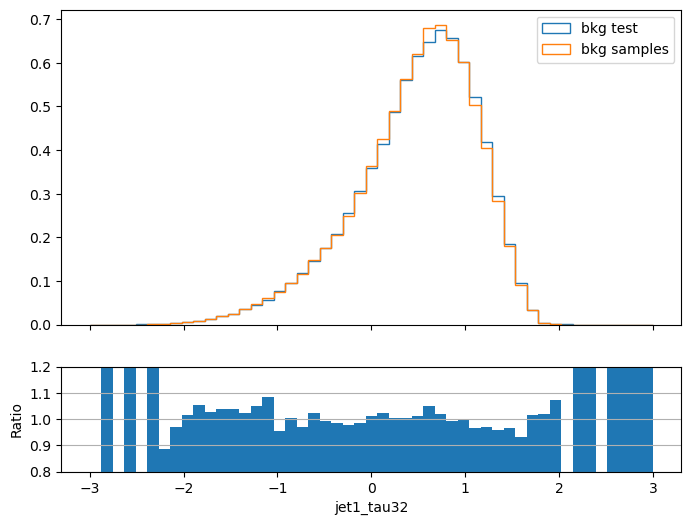

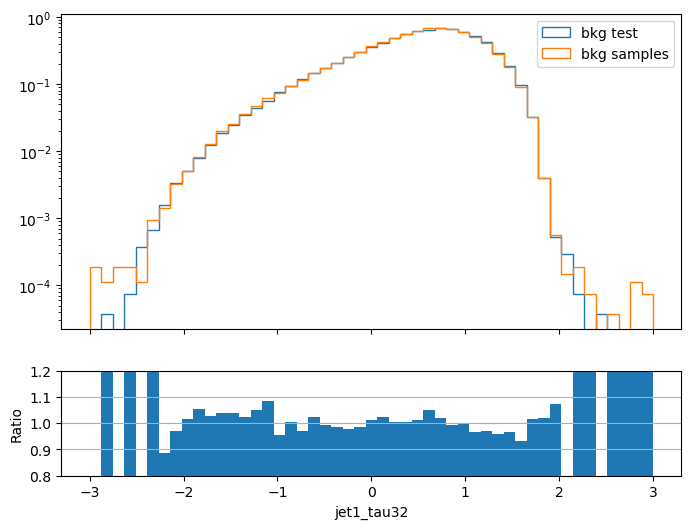

In [14]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":10,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step2_jet1_tau32


Loss: 0.8868969476222992, p = 124: 100%|██████████| 878/878 [02:58<00:00,  4.91it/s]


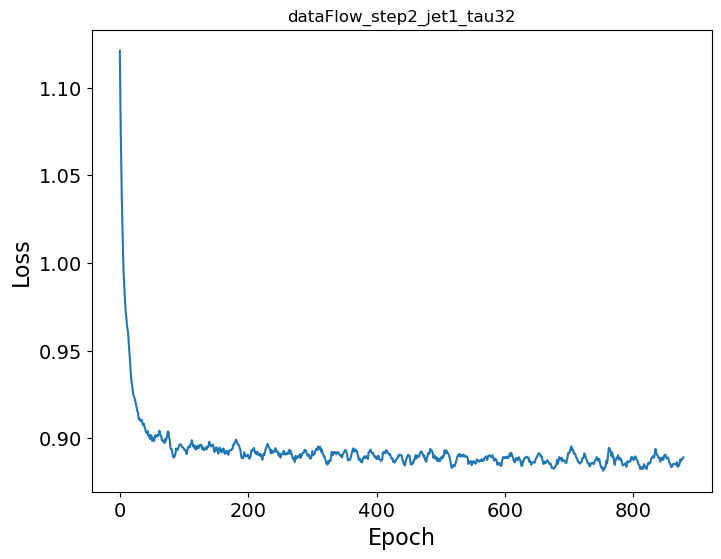

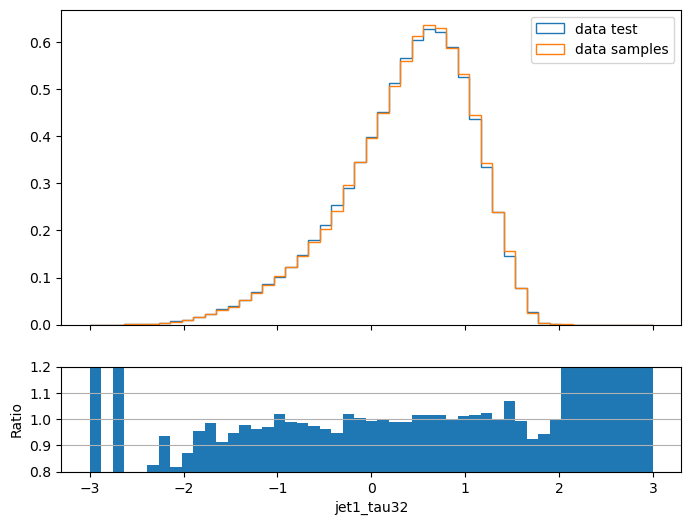

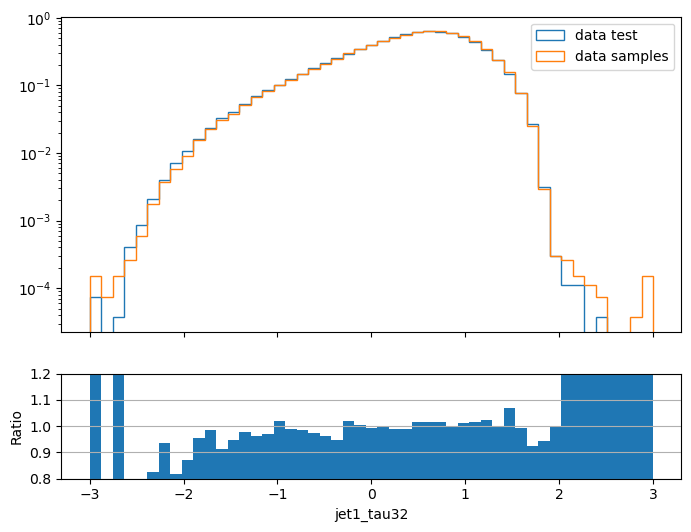

In [15]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":10,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 22/22 [00:01<00:00, 11.95it/s]


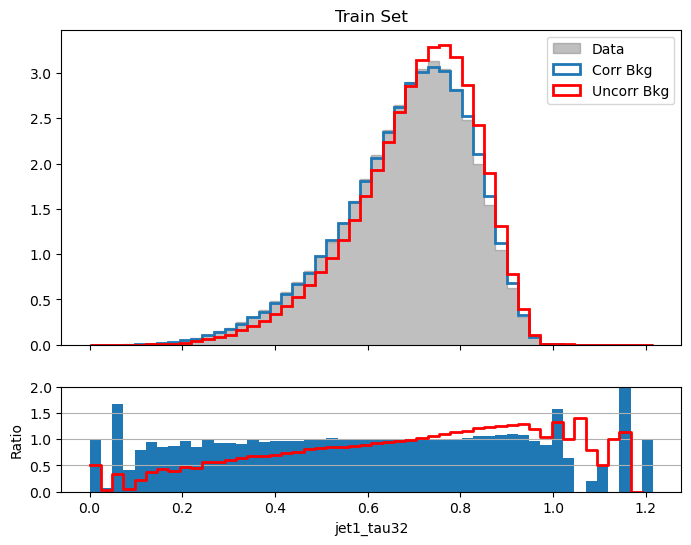

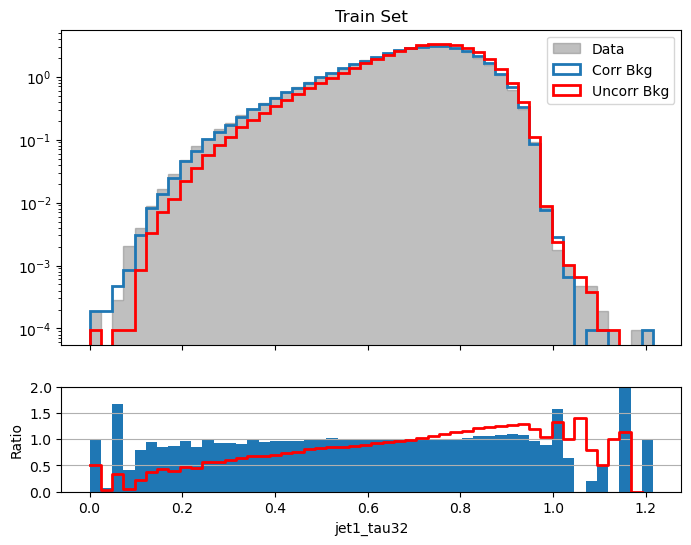

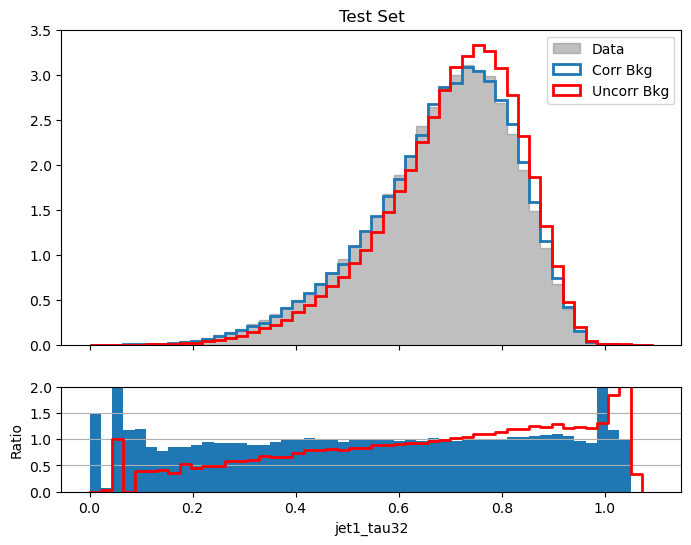

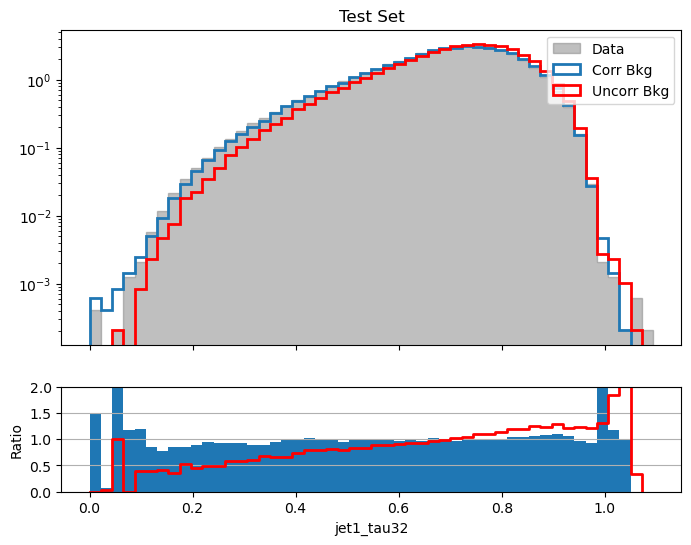

In [16]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [17]:
trainer.stepForward()

## jet1 tau43

Training flow bkgFlow_step3_jet1_tau43


Loss: 0.36085320591926573, p = 127: 100%|██████████| 1318/1318 [03:32<00:00,  6.21it/s]


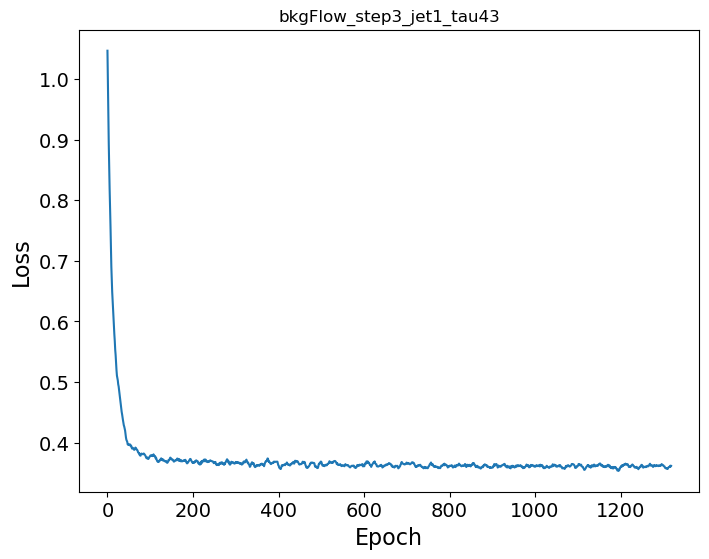

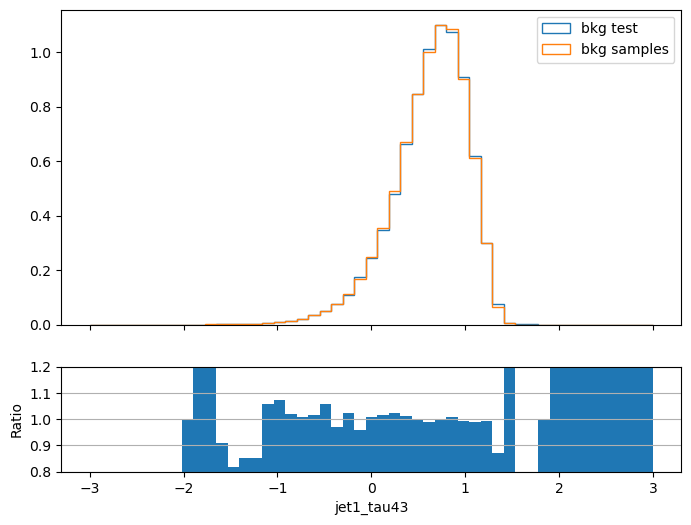

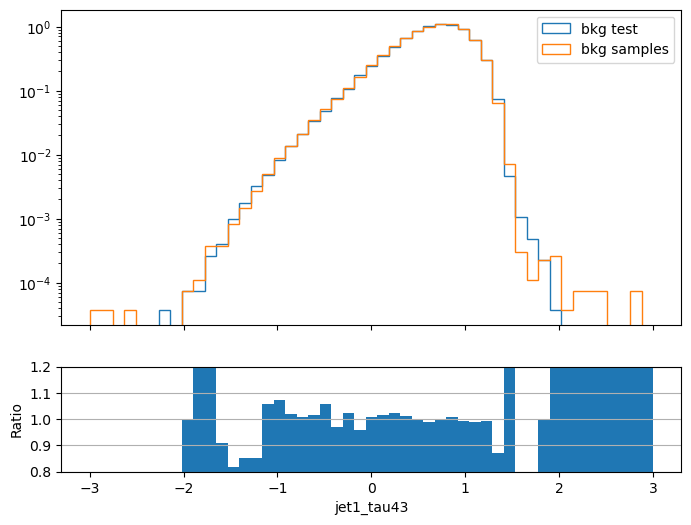

In [18]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":1,"num_bins":10,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 30
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step3_jet1_tau43


Loss: 0.4274661475419998, p = 566: 100%|██████████| 1317/1317 [03:33<00:00,  6.18it/s] 


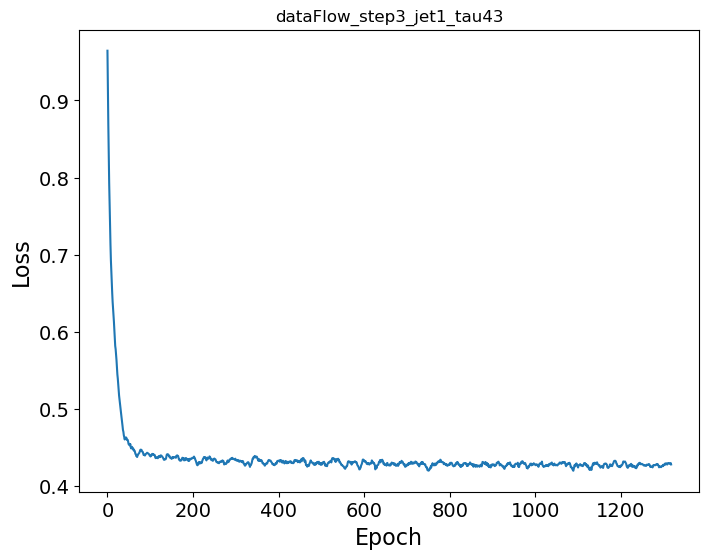

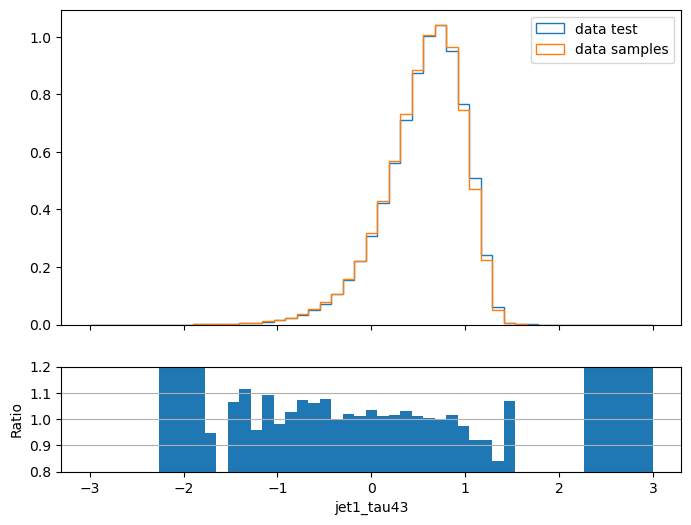

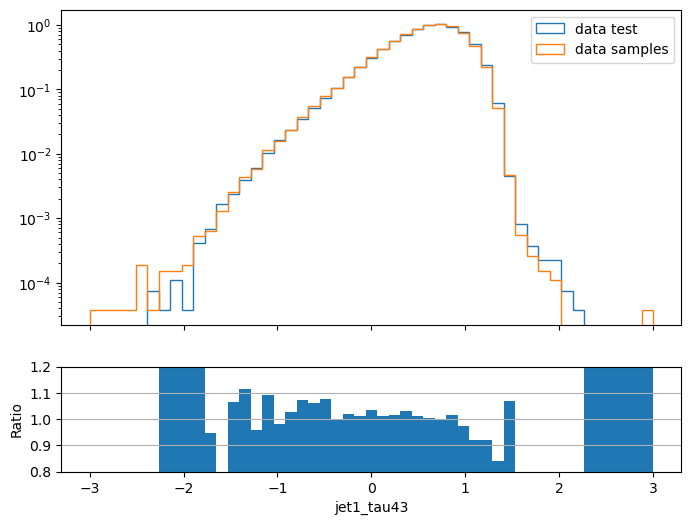

In [19]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":1,"num_bins":10,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 30
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 22/22 [00:00<00:00, 43.83it/s]


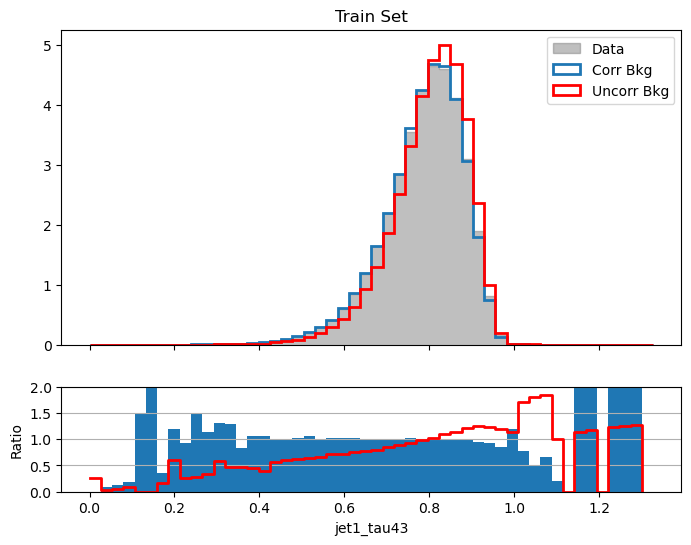

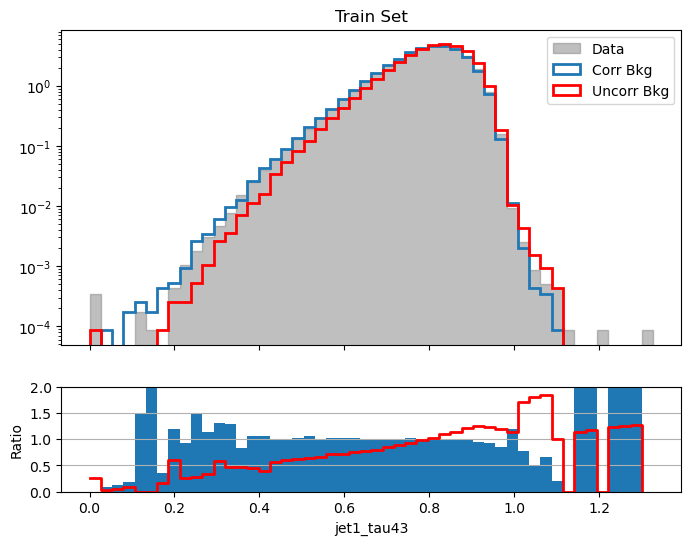

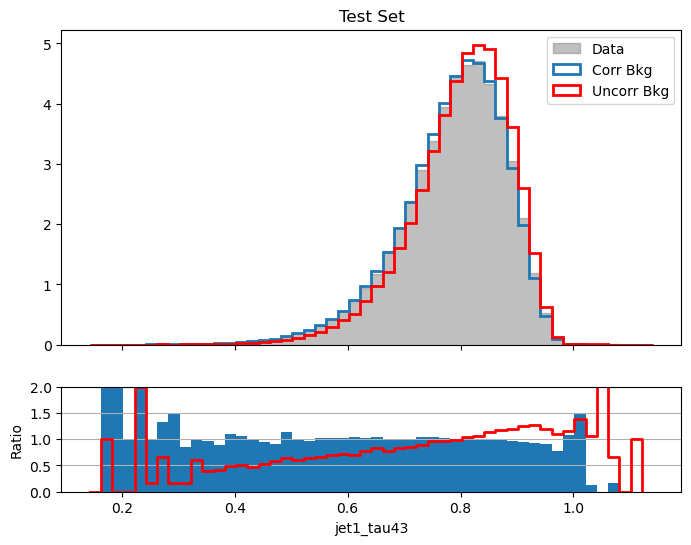

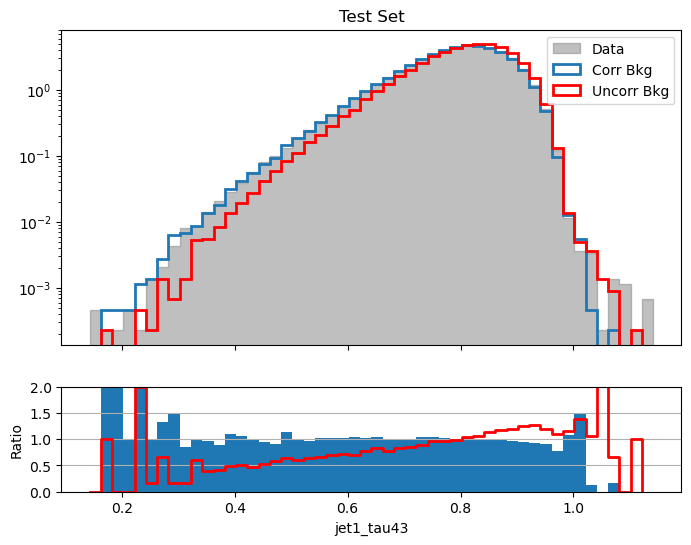

In [21]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [22]:
trainer.stepForward()

## jet2 rho

Training flow bkgFlow_step4_jet2_rho


Loss: 0.46592947691679, p = 109: 100%|██████████| 878/878 [03:00<00:00,  4.86it/s]   


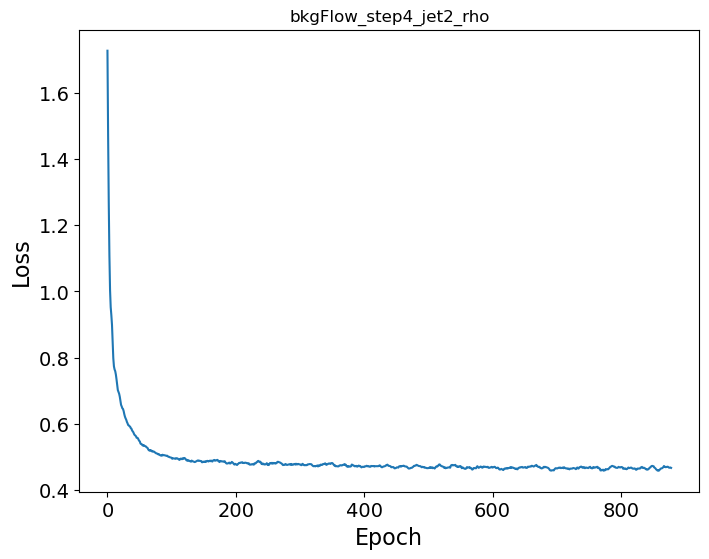

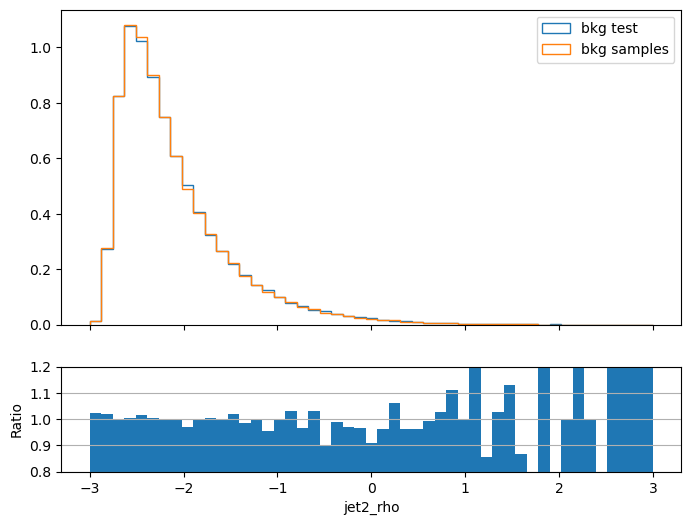

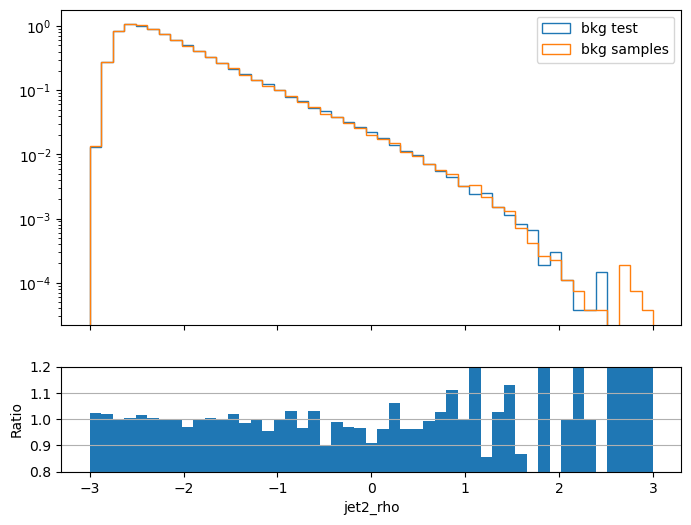

In [23]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":20,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step4_jet2_rho


Loss: 0.5333550959825516, p = 99: 100%|██████████| 878/878 [02:58<00:00,  4.93it/s] 


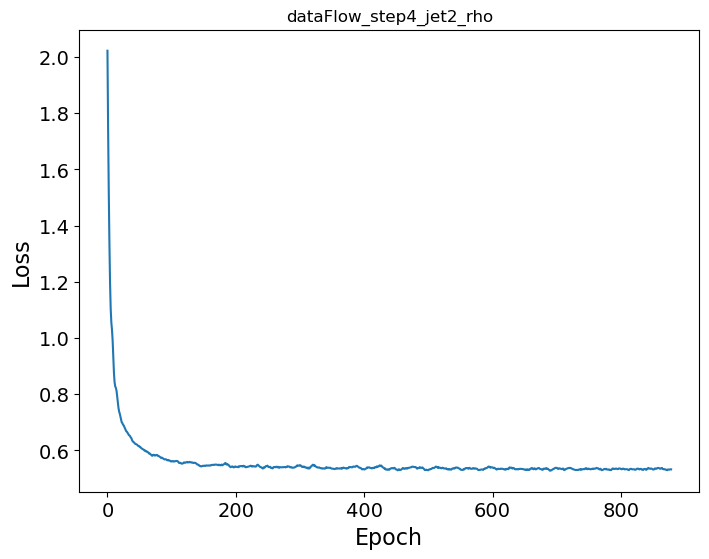

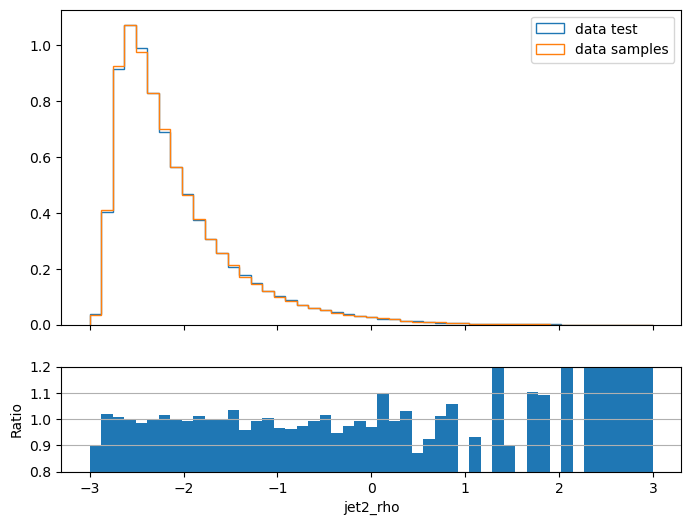

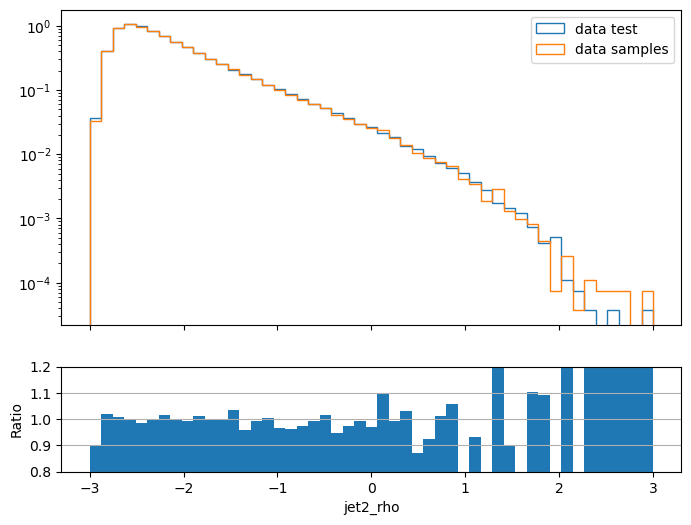

In [24]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":20,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 22/22 [00:02<00:00,  8.46it/s]


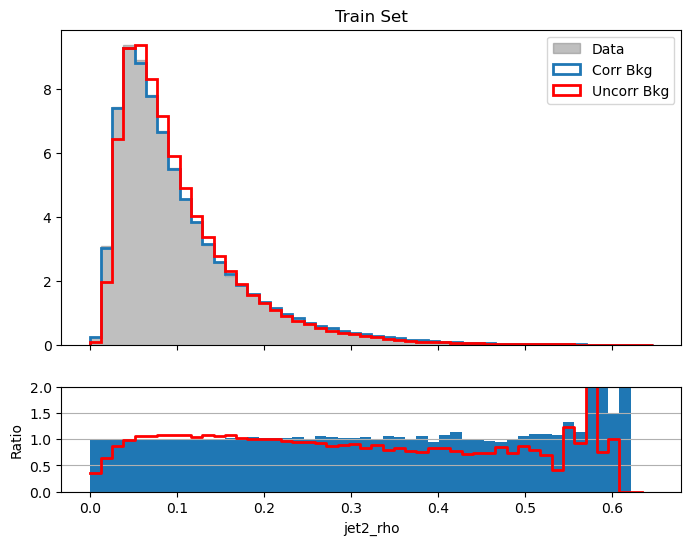

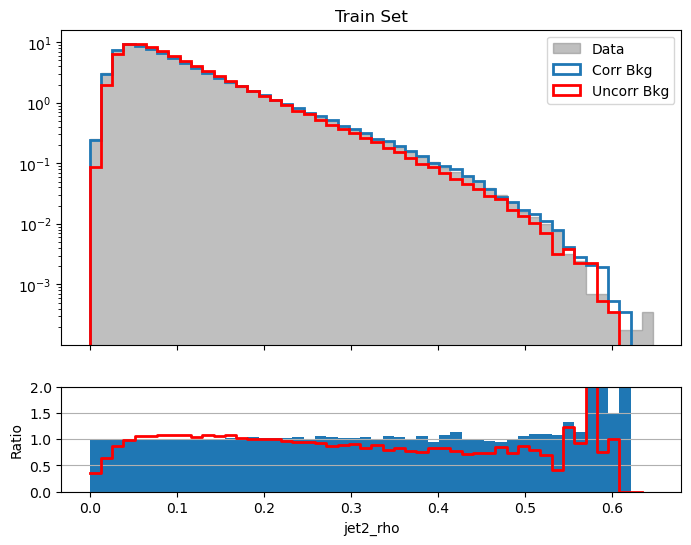

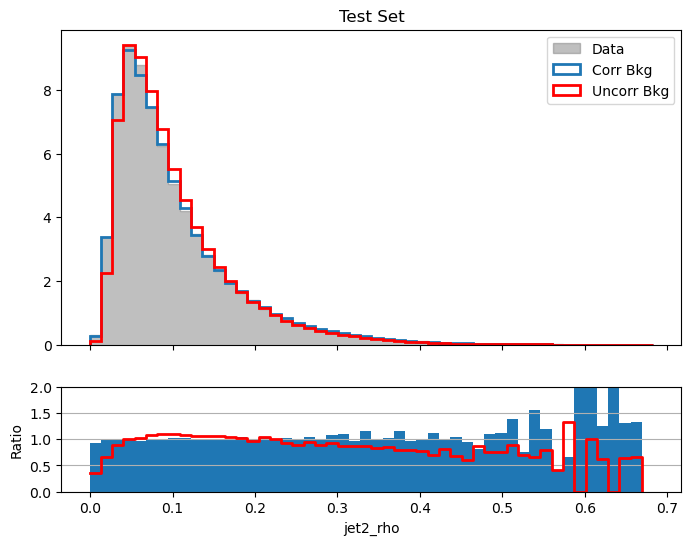

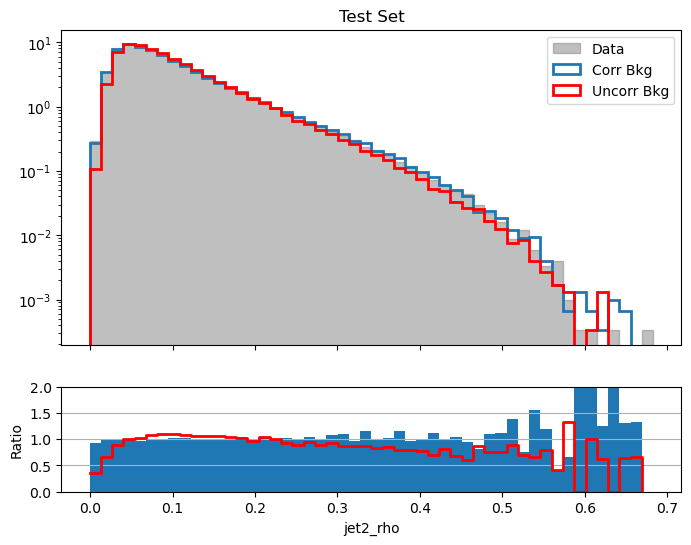

In [25]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [26]:
trainer.stepForward()

## jet2 tau21

Training flow bkgFlow_step5_jet2_tau21


Loss: 1.361270545721054, p = 40: 100%|██████████| 878/878 [03:39<00:00,  4.00it/s]  


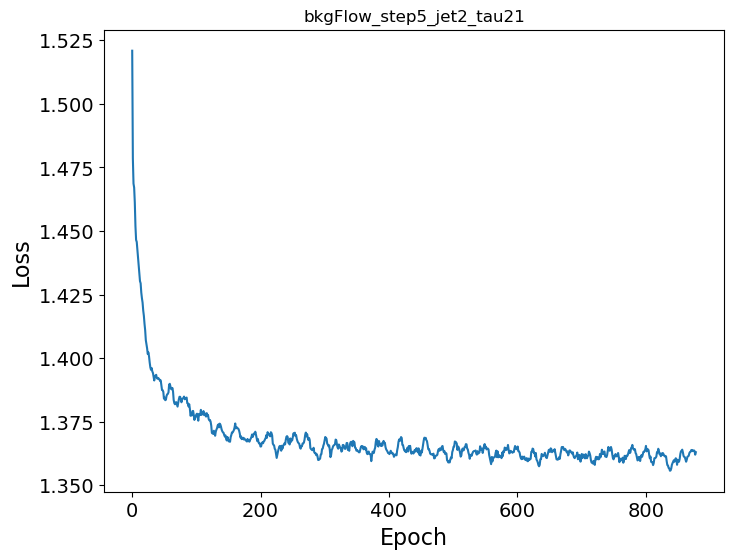

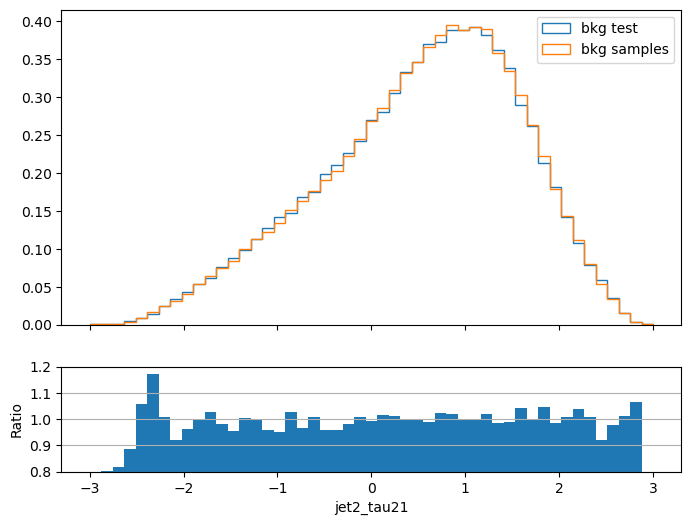

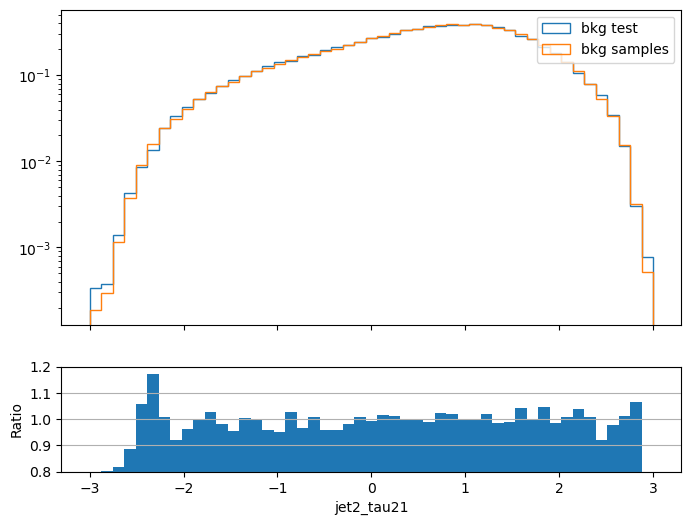

In [29]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":20,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step5_jet2_tau21


Loss: 1.3962195420265198, p = 273: 100%|██████████| 878/878 [03:40<00:00,  3.98it/s]


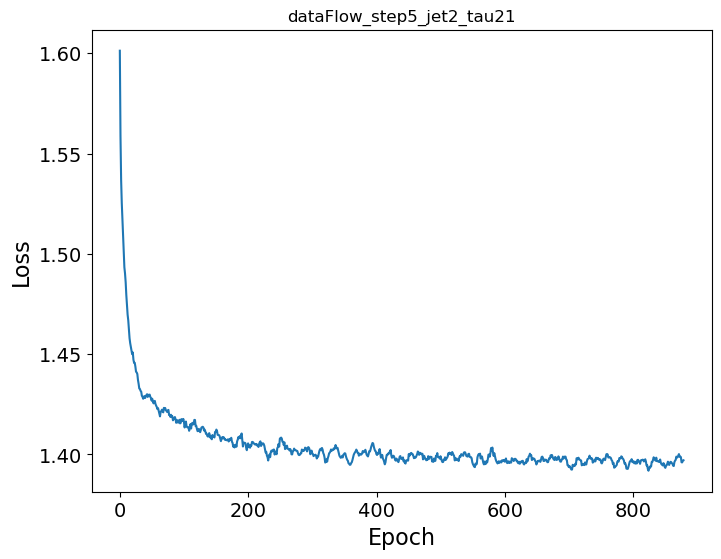

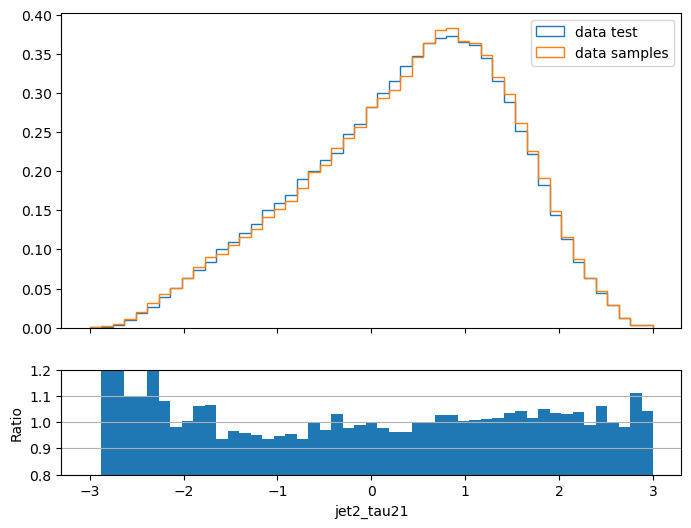

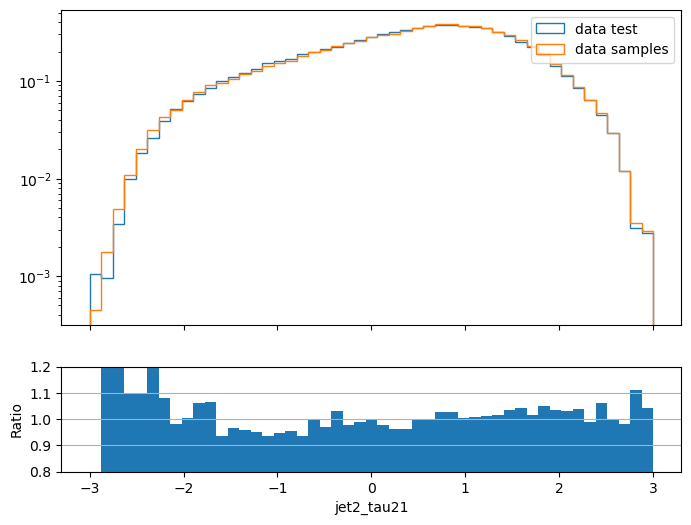

In [30]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":20,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 22/22 [00:02<00:00,  8.18it/s]


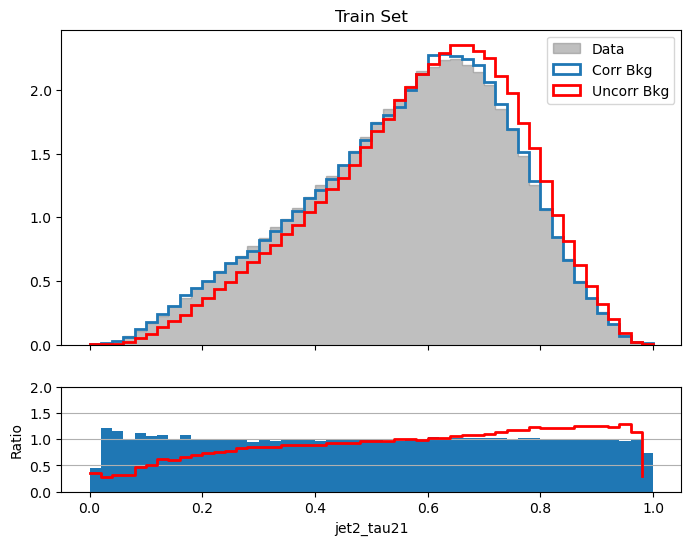

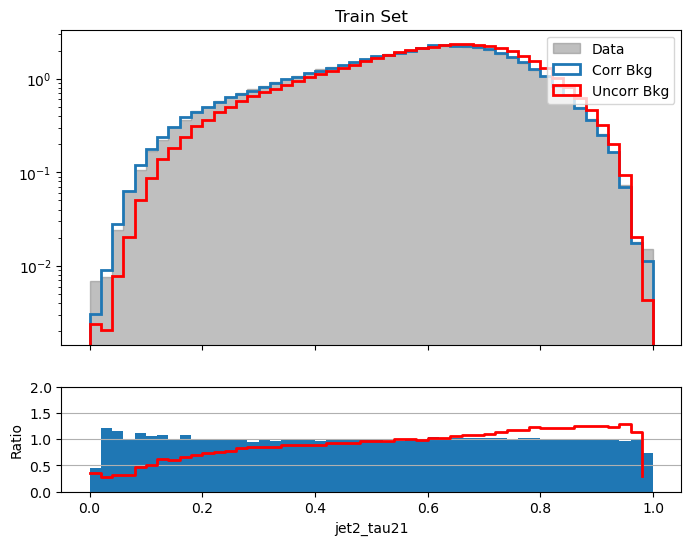

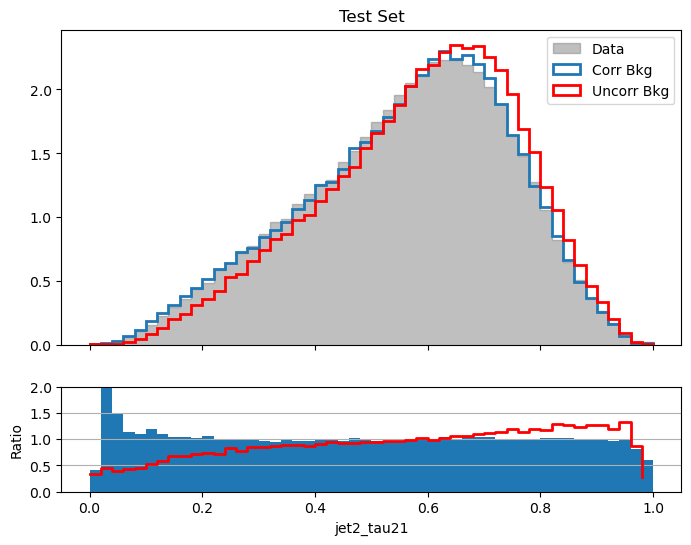

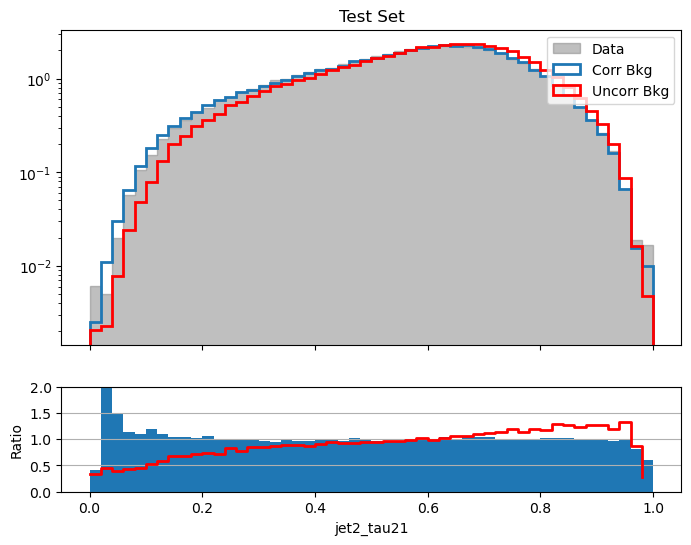

In [31]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [32]:
trainer.stepForward()

## jet2 tau32

Training flow bkgFlow_step6_jet2_tau32


Loss: 0.7196521949768067, p = 126: 100%|██████████| 878/878 [02:27<00:00,  5.96it/s]


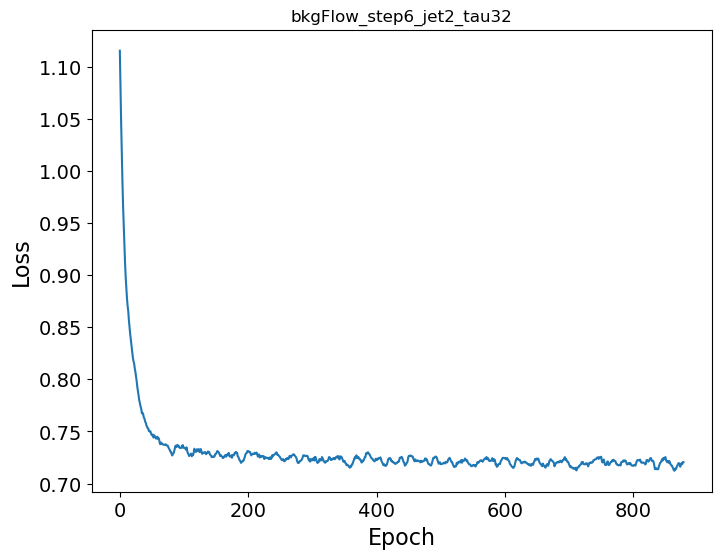

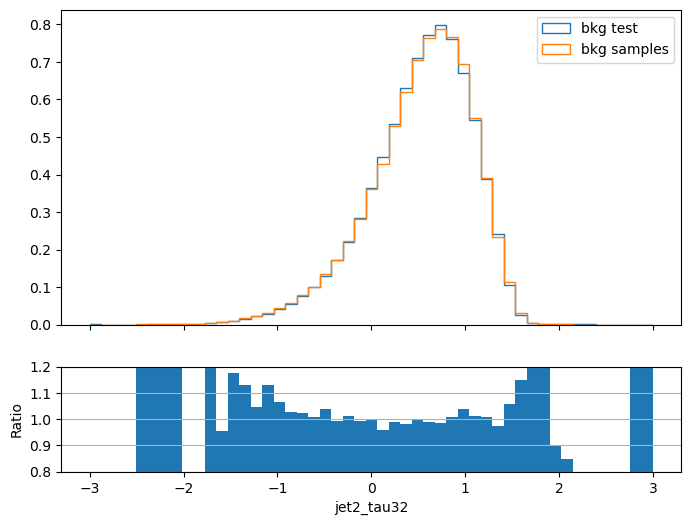

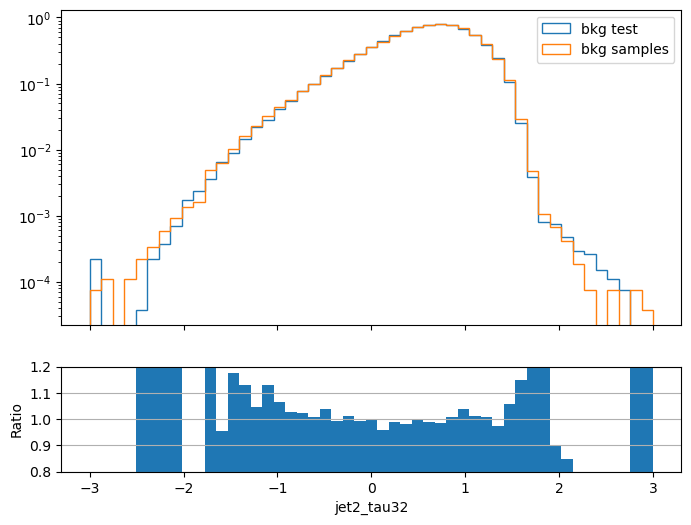

In [33]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":1,"num_bins":10,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step6_jet2_tau32


Loss: 0.781877618432045, p = 168: 100%|██████████| 878/878 [02:22<00:00,  6.15it/s] 


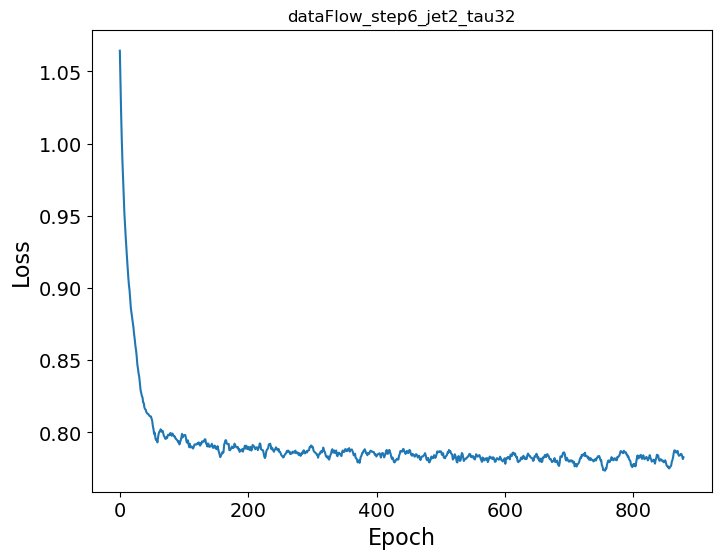

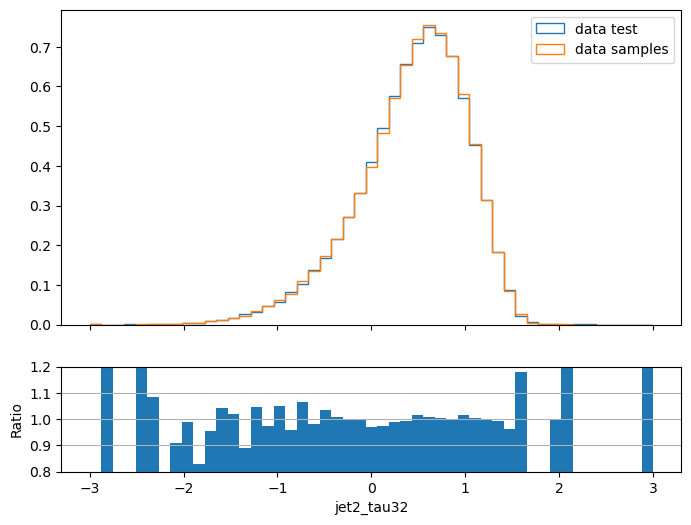

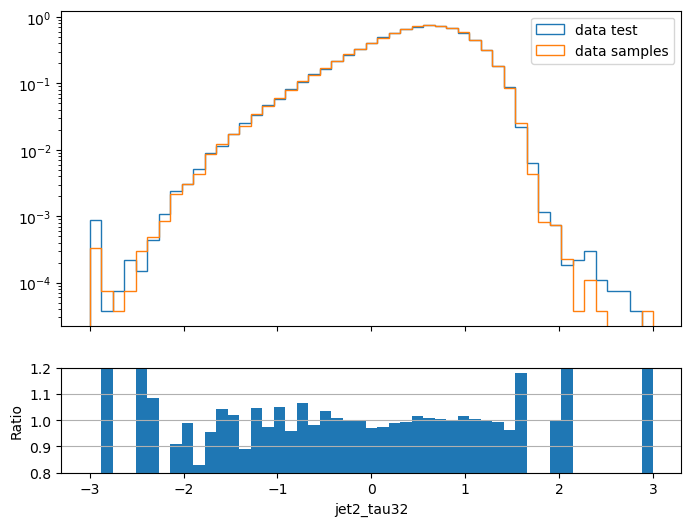

In [34]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":1,"num_bins":10,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 22/22 [00:00<00:00, 47.23it/s]


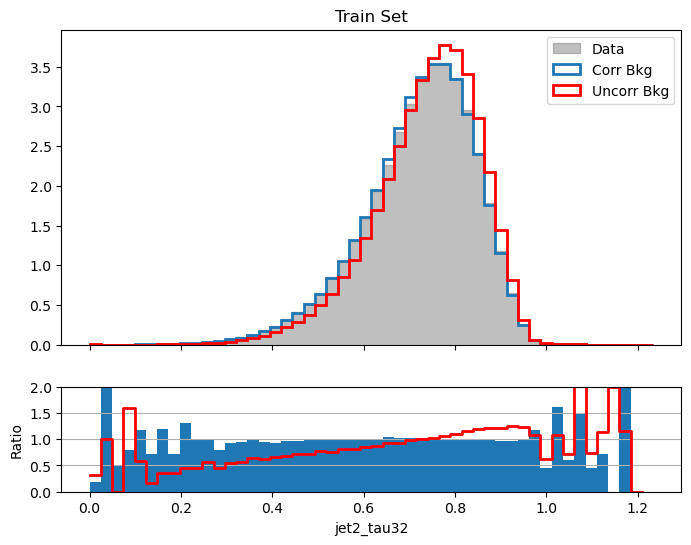

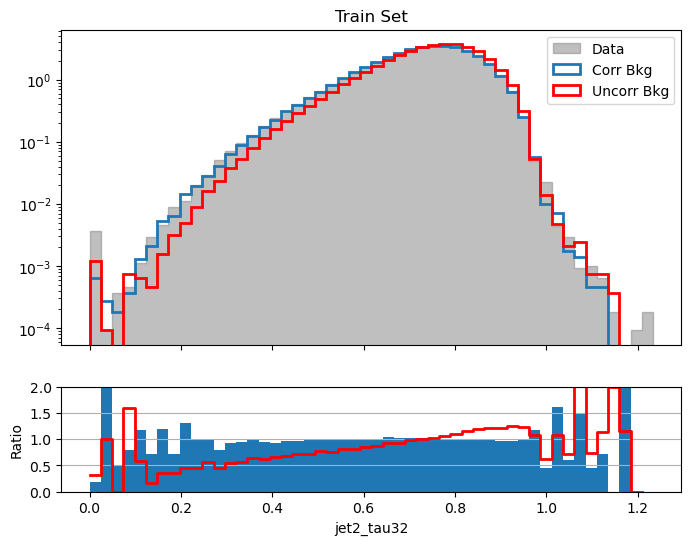

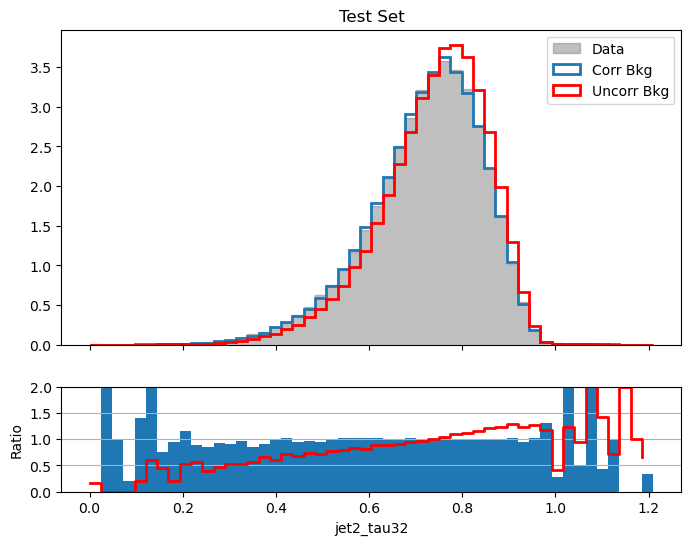

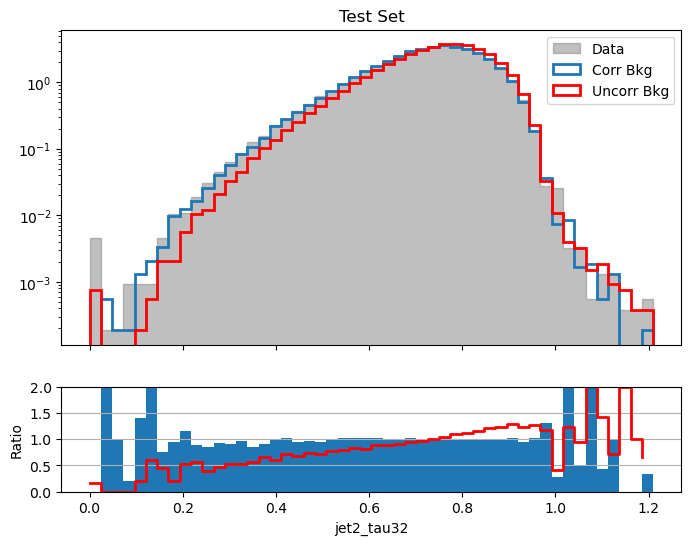

In [35]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [36]:
trainer.stepForward()

## jet2 tau43

Training flow bkgFlow_step7_jet2_tau43


Loss: 0.42955597341060636, p = 50: 100%|██████████| 1318/1318 [04:30<00:00,  4.87it/s] 


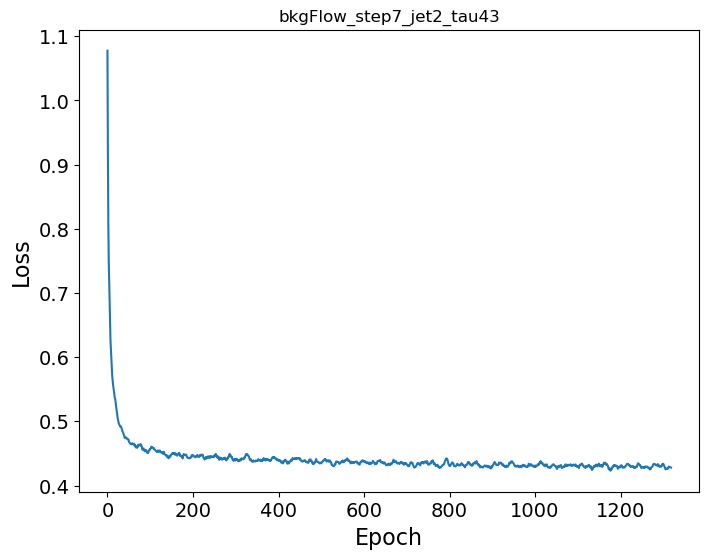

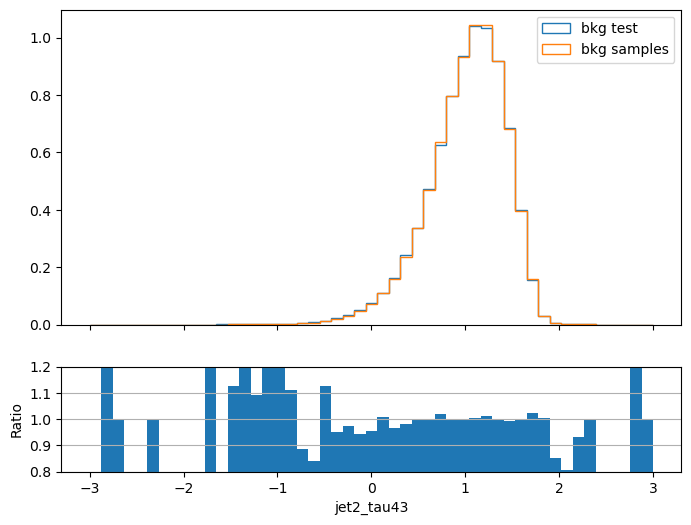

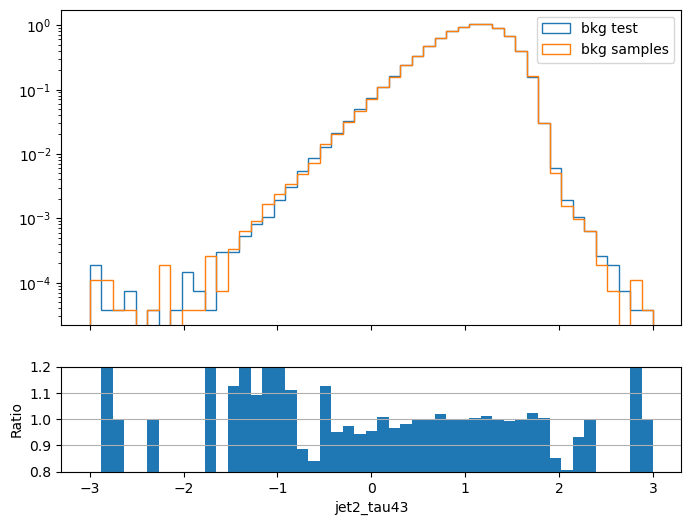

In [39]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":10,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 30
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

In [ ]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":10,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 30
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

Training flow dataFlow_step7_jet2_tau43


Loss: 0.5158244758844376, p = 13:  17%|█▋        | 228/1317 [00:46<03:40,  4.94it/s]

100%|██████████| 26/26 [00:02<00:00, 11.05it/s]


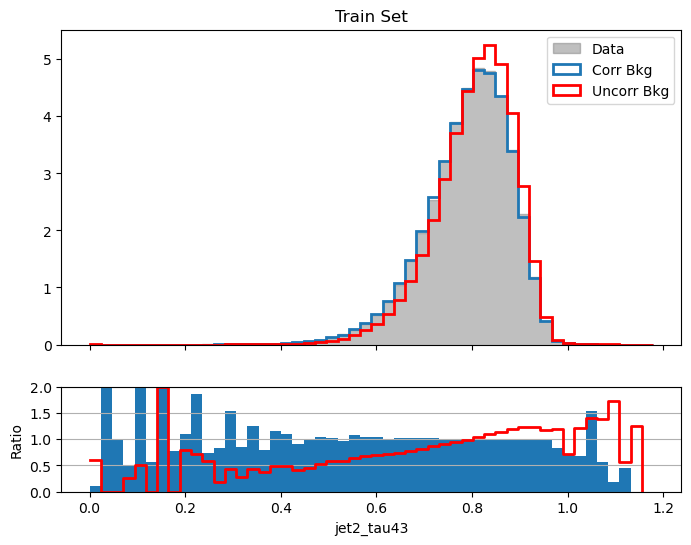

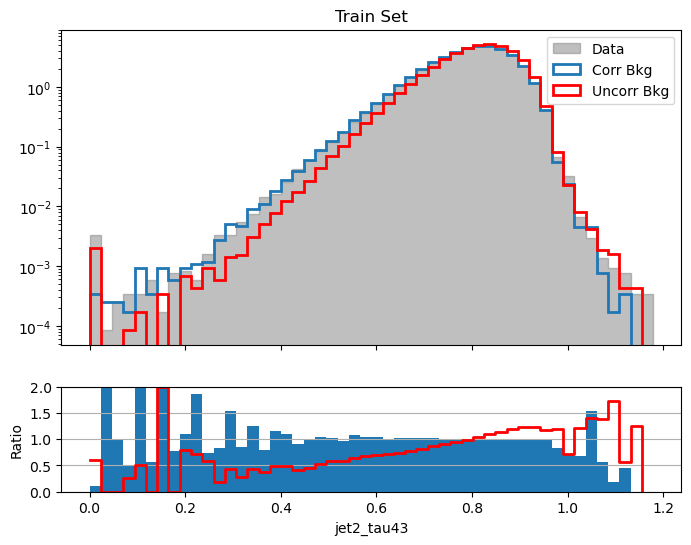

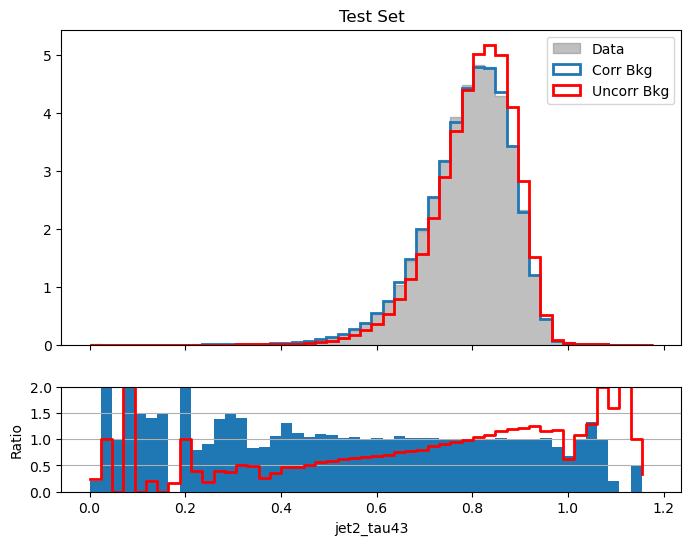

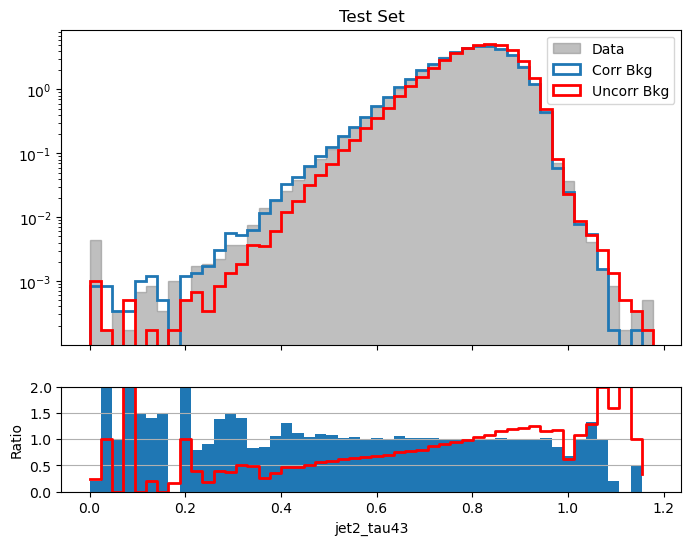

In [68]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])